# AI3I - NCAA March Mania 2025

Predicting the outcomes of March-Madness!

### Problem overview

Each season there are thousands of NCAA® basketball games played between Division I college basketball teams, culminating in March Madness®, the national championship men's and women's tournaments that run from mid-March until their championship games in early April. We have a large amount of historical data about college basketball games and teams, going back many years. Armed with this historical data, we explore it and develop our way of predicting March Madness® game outcomes.

### Dataset description

Our dataset contains men's and women's regular season and NCAA® tournament results with team box-score statistics for every game, from season 2003 until 2025. Each season, a team accessing the NCAA® tournament is assigned with a seed, which is used to create the matchups; a dataset with all the seeds of those teams that accessed the tournament is available.  
**For men's only**, ordinal rankings assigned from various ranking systems are available, from season 2003 onwards.

### Project's goal

The goal of the project is to use regular season results to create features for each team, and use such features to predict the outcomes of the NCAA® tournament. We will use data from season 2003-2024 as training/validation, and season 2025 to test our predictions.

### Evaluation metric

The competition rank solutions based on the **Brier score** (mean squared error between predicted probability and outcome):

$$\text{Brier} = \frac{1}{N}\sum_{i=1}^{N}(p_i - y_i)^2$$



In [107]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn
import warnings,os
import xgboost as xgb
import optuna
from sklearn.metrics import log_loss, brier_score_loss, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from scipy.interpolate import UnivariateSpline

warnings.filterwarnings("ignore")
pd.set_option("display.max_column", 999) # to visualize all the columns

## Data Loading

In [108]:
data_dir = "/Users/shariqansari/Downloads/march-machine-learning-mania-2026"

# M -> men's basketball
M_regular_results_df = pd.read_csv(f"{data_dir}/MRegularSeasonDetailedResults.csv")
M_tourney_results_df = pd.read_csv(f"{data_dir}/MNCAATourneyDetailedResults.csv")
M_seeds_df = pd.read_csv(f"{data_dir}/MNCAATourneySeeds.csv")
M_massey_ordinals_df = pd.read_csv(f"{data_dir}/MMasseyOrdinals.csv")

# W -> women's basketball 
W_regular_results_df = pd.read_csv(f"{data_dir}/WRegularSeasonDetailedResults.csv")
W_tourney_results_df = pd.read_csv(f"{data_dir}/WNCAATourneyDetailedResults.csv")
W_seeds_df = pd.read_csv(f"{data_dir}/WNCAATourneySeeds.csv")


def _load_teams(path, fallback_path=None):
    for p in [path, fallback_path]:
        if p and os.path.exists(p):
            return pd.read_csv(p)[['TeamID','TeamName']]
    return pd.DataFrame(columns=['TeamID','TeamName'])

M_teams_lookup = _load_teams(
    f"{data_dir}/MTeams.csv",
    f"{data_dir}/mteams.csv"
)
W_teams_lookup = _load_teams(
    f"{data_dir}/WTeams.csv",
    f"{data_dir}/wteams.csv"
)

We tag each dataset with a `Category` column (0 = Men, 1 = Women) and concatenate Men's and Women's data into unified DataFrames. Training on both categories simultaneously gives the model more data and lets it learn shared basketball patterns.

In [109]:
category = {"Men":0, "Women":1}

M_regular_results_df["Category"] = category["Men"]
M_tourney_results_df["Category"] = category["Men"]
W_regular_results_df["Category"] = category["Women"]
W_tourney_results_df["Category"] = category["Women"]

In [110]:
regular_results_df = pd.concat([M_regular_results_df, W_regular_results_df])
tourney_results_df = pd.concat([M_tourney_results_df, W_tourney_results_df])
seeds_df = pd.concat([M_seeds_df, W_seeds_df])

## Data exploration

In [111]:
regular_results_df.head()

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,WFGM3,WFGA3,WFTM,WFTA,WOR,WDR,WAst,WTO,WStl,WBlk,WPF,LFGM,LFGA,LFGM3,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF,Category
0,2003,10,1104,68,1328,62,N,0,27,58,3,14,11,18,14,24,13,23,7,1,22,22,53,2,10,16,22,10,22,8,18,9,2,20,0
1,2003,10,1272,70,1393,63,N,0,26,62,8,20,10,19,15,28,16,13,4,4,18,24,67,6,24,9,20,20,25,7,12,8,6,16,0
2,2003,11,1266,73,1437,61,N,0,24,58,8,18,17,29,17,26,15,10,5,2,25,22,73,3,26,14,23,31,22,9,12,2,5,23,0
3,2003,11,1296,56,1457,50,N,0,18,38,3,9,17,31,6,19,11,12,14,2,18,18,49,6,22,8,15,17,20,9,19,4,3,23,0
4,2003,11,1400,77,1208,71,N,0,30,61,6,14,11,13,17,22,12,14,4,4,20,24,62,6,16,17,27,21,15,12,10,7,1,14,0


Massey ordinals contains ranking assigned by external systems. It exists for men's competition only

In [112]:
M_massey_ordinals_df

,Season,RankingDayNum,SystemName,TeamID,OrdinalRank
0,2003,35,SEL,1102,159
1,2003,35,SEL,1103,229
2,2003,35,SEL,1104,12
3,2003,35,SEL,1105,314
4,2003,35,SEL,1106,260
...,...,...,...,...,...
5864996,2026,133,WLS,1477,318
5864997,2026,133,WLS,1478,303
5864998,2026,133,WLS,1479,287
5864999,2026,133,WLS,1480,293


Do we have nan values?

In [113]:
print("NaN values?")
print("")
print(f"Regular Season results: {any(regular_results_df.isna().any())}")
print(f"Tourney results:        {any(tourney_results_df.isna().any())}")
print(f"Ordinal rankings:       {any(M_massey_ordinals_df.isna().any())}")

NaN values?

Regular Season results: False
Tourney results:        False
Ordinal rankings:       False


Let's see the journey of a team during last season

In [114]:
season = 2025
team_id = 1104

r = regular_results_df[
    (regular_results_df["Season"]==season) & 
    ((regular_results_df["WTeamID"]==team_id) | (regular_results_df["LTeamID"]==team_id))]

t = tourney_results_df[
    (tourney_results_df["Season"]==season) & 
    ((tourney_results_df["WTeamID"]==team_id) | (tourney_results_df["LTeamID"]==team_id))]

r["Type"] = "regular season"
t["Type"] = "tournament"

rt = pd.concat([r,t])
rt["Outcome"] = np.where(rt["WTeamID"] == team_id, "win", "lose")

rt[["DayNum", "WScore", "LScore", "Type", "Outcome"]]

,DayNum,WScore,LScore,Type,Outcome
113241,0,110,54,regular season,win
113411,4,88,79,regular season,win
113547,7,72,64,regular season,win
113724,11,87,78,regular season,lose
113916,16,100,87,regular season,win
114219,22,85,80,regular season,win
114275,23,95,90,regular season,win
114447,26,83,81,regular season,lose
114563,30,94,79,regular season,win
114859,40,83,75,regular season,win


### Ranking stats
Seeds describe team's ranking (according to experts) based on their prior performance throughout the regular season. They are alphanumeric strings, with the first character determining the region of the team. An additional letter is added to distinguish teams belonging to the same region. We will use only the digits of the seed to represent their ranking.

NB: only tournament's teams are assigned with a seed

In [115]:
seeds_df[["Seed"]].drop_duplicates()

,Seed
0,W01
1,W02
2,W03
3,W04
4,W05
...,...
2551,Z10b
1670,Z12a
1671,Z12b
1769,X10a


Which seeds did our team have? Which average ordinal ranking?

In [116]:
seeds_df[(seeds_df["Season"]==season) & (seeds_df["TeamID"]==team_id)]

,Season,Seed,TeamID
2559,2025,W02,1104


Let's compute mean `OrdinalRank` across all ranking systems for team 1104 during season 2025, grouped by ranking day.

In [117]:
M_massey_ordinals_df[(M_massey_ordinals_df["Season"]==season) & (M_massey_ordinals_df["TeamID"]==team_id)].groupby("RankingDayNum")["OrdinalRank"].mean().reset_index().tail(5)

,RankingDayNum,OrdinalRank
14,107,4.173077
15,114,5.094340
16,121,4.981818
17,128,5.035714
18,133,5.553571


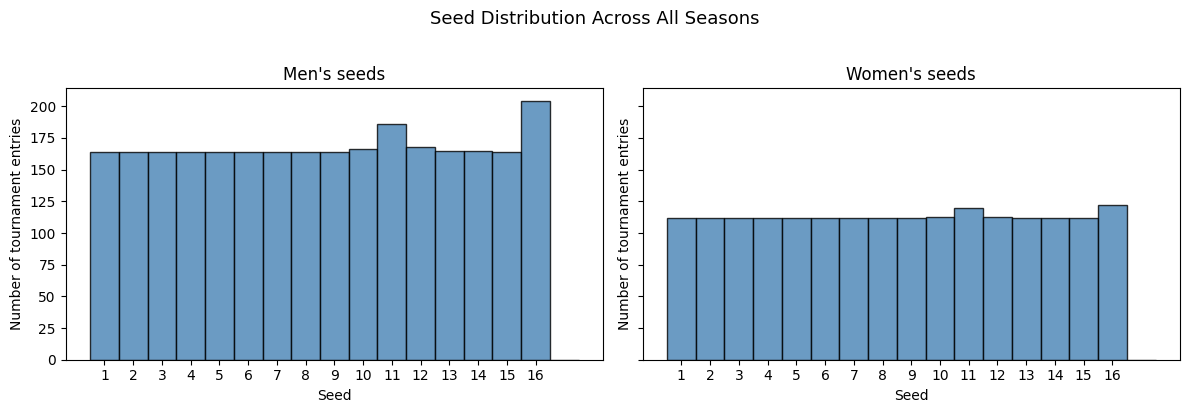

In [118]:
# distribution of numeric seeds across all seasons, for Men and Women
int_seeds_M = M_seeds_df['Seed'].map(lambda x: int(x[1:3]))
int_seeds_W = W_seeds_df['Seed'].map(lambda x: int(x[1:3]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, seeds, title in zip(axes, [int_seeds_M, int_seeds_W], ["Men's seeds", "Women's seeds"]):
    ax.hist(seeds, bins=range(1, 19), edgecolor='black', align='left', color='steelblue', alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel('Seed')
    ax.set_ylabel('Number of tournament entries')
    ax.set_xticks(range(1, 17))
plt.suptitle('Seed Distribution Across All Seasons', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

Some games do not end at the regular time and 1 or more OT (overtime) are played. This means that stats are collected for a longer time (higher scored points, rebounds, etc.)

In [119]:
regular_results_df["NumOT"].value_counts().plot(kind="bar")

<Axes: xlabel='NumOT'>

Is winning at home easier than winning away?

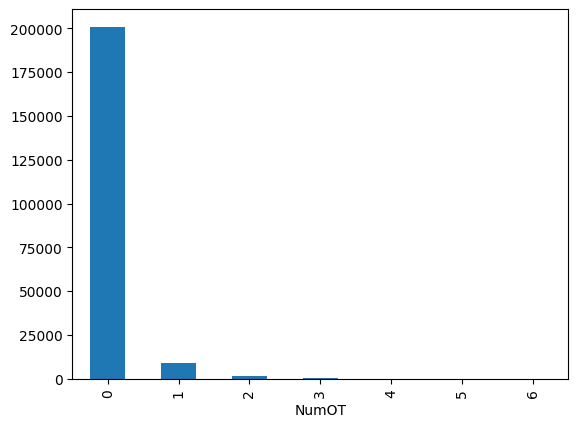

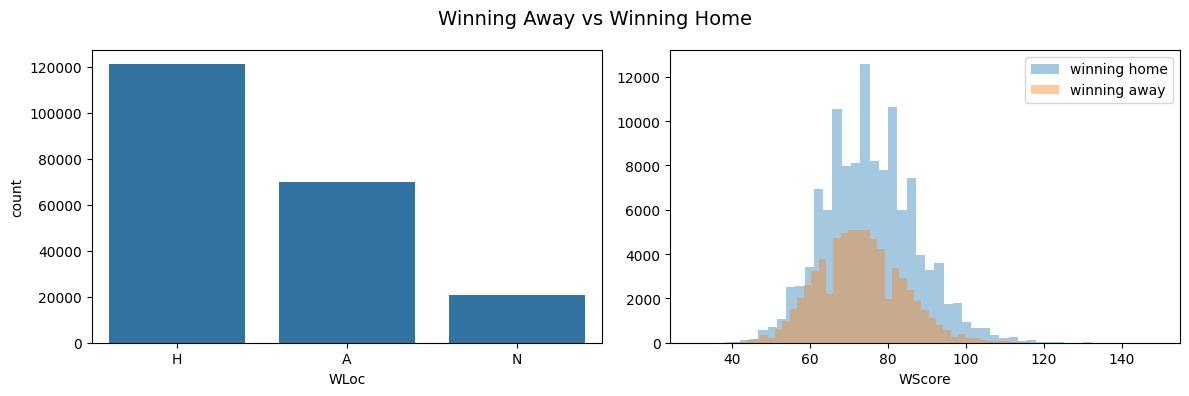

In [120]:
s1 = regular_results_df[regular_results_df["WLoc"]== "H"]["WScore"]
s2 = regular_results_df[regular_results_df["WLoc"]== "A"]["WScore"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

seaborn.barplot(x=regular_results_df["WLoc"].value_counts().index, 
                y=regular_results_df["WLoc"].value_counts(),
                ax=axes[0])
seaborn.distplot(s1, label="winning home", kde=False, ax=axes[1])
seaborn.distplot(s2, label="winning away", kde=False, ax=axes[1])

axes[1].legend()
plt.suptitle('Winning Away vs Winning Home', fontsize=14)
plt.tight_layout()
plt.show()

we can take into account the home advantage by correcting the raw scores with the mean differences. 

In [121]:
home_score_mean = s1.mean()
away_score_mean = s2.mean()
home_advantage = (home_score_mean - away_score_mean)/2

print(f"The mean score when winning home is: {home_score_mean}")
print(f"The mean score when winning away is: {away_score_mean}")
print("")
print(f"Mean home advantage points is: {home_score_mean - away_score_mean}") ## why not display corrected advantage

The mean score when winning home is: 75.3961703532519
The mean score when winning away is: 72.77674365325964

Mean home advantage points is: 2.6194266999922604


Stats percentages might capture better the average performance of a team throughout a season with respect to raw stats

In [122]:
rr = regular_results_df.copy()

rr["WFG%"] = rr["WFGM"]/rr["WFGA"]
rr["WFG%3"] = rr["WFGM3"]/rr["WFGA3"]
rr["WFT%"] = rr["WFTM"]/rr["WFTA"]

rr["LFG%"] = rr["LFGM"]/rr["LFGA"]
rr["LFG%3"] = rr["LFGM3"]/rr["LFGA3"]
rr["LFT%"] = rr["LFTM"]/rr["LFTA"]

columns_to_describe = ['WScore','LScore','WLoc','WFGM','WFGA','WFG%',
                       'WFGM3','WFGA3','WFG%3','WFTM','WFTA','WFT%','WOR',
                       'WDR','WAst','WTO','WStl','WBlk','WPF',
                       'LFGM','LFGA','LFG%','LFGM3','LFGA3','LFG%3',
                       'LFTM','LFTA','LFT%','LOR','LDR','LAst','LTO',
                       'LStl','LBlk','LPF']
winning_teams_columns = [c for c in columns_to_describe if c.startswith("W")]
losing_teams_columns = [c for c in columns_to_describe if c.startswith("L")]

In [123]:
rr[winning_teams_columns].describe()

,WScore,WFGM,WFGA,WFG%,WFGM3,WFGA3,WFG%3,WFTM,WFTA,WFT%,WOR,WDR,WAst,WTO,WStl,WBlk,WPF
count,211716.000000,211716.000000,211716.000000,211716.000000,211716.000000,211716.000000,211702.000000,211716.000000,211716.000000,211688.000000,211716.000000,211716.000000,211716.000000,211716.000000,211716.000000,211716.000000,211716.000000
mean,74.347182,26.237209,57.166081,0.460710,6.963810,18.940973,0.365366,14.908954,20.851622,0.715244,10.973960,25.962469,14.838156,13.492216,7.672505,3.732968,16.683028
std,11.458923,4.821583,7.811166,0.068897,3.183975,6.366821,0.117219,6.112946,7.971070,0.118703,4.461546,5.090498,4.530240,4.464958,3.495792,2.417302,4.214254
min,30.000000,9.000000,26.000000,0.180000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,66.000000,23.000000,52.000000,0.413793,5.000000,14.000000,0.285714,11.000000,15.000000,0.642857,8.000000,22.000000,12.000000,10.000000,5.000000,2.000000,14.000000
50%,74.000000,26.000000,57.000000,0.459459,7.000000,19.000000,0.363636,14.000000,20.000000,0.722222,11.000000,26.000000,15.000000,13.000000,7.000000,3.000000,16.000000
75%,82.000000,29.000000,62.000000,0.508197,9.000000,23.000000,0.441176,19.000000,26.000000,0.800000,14.000000,29.000000,18.000000,16.000000,10.000000,5.000000,19.000000
max,149.000000,58.000000,113.000000,0.800000,30.000000,63.000000,1.000000,50.000000,67.000000,1.000000,45.000000,58.000000,45.000000,40.000000,36.000000,21.000000,42.000000


In [124]:
rr[losing_teams_columns].describe()

,LScore,LFGM,LFGA,LFG%,LFGM3,LFGA3,LFG%3,LFTM,LFTA,LFT%,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
count,211716.000000,211716.000000,211716.000000,211716.000000,211716.000000,211716.000000,211709.000000,211716.000000,211716.000000,211581.000000,211716.00000,211716.000000,211716.000000,211716.000000,211716.000000,211716.000000,211716.000000
mean,61.307204,22.055338,57.335029,0.386048,5.734385,19.376311,0.292827,11.462143,16.826839,0.679926,10.68812,21.860960,11.232481,15.130113,6.462365,2.850262,18.797054
std,11.413701,4.498934,7.725899,0.067848,2.822170,6.359618,0.109315,5.248387,6.986135,0.138866,4.40488,4.704645,3.770125,5.044259,2.985238,2.033009,4.585103
min,11.000000,3.000000,25.000000,0.060000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000,0.000000,0.000000,0.000000,3.000000
25%,54.000000,19.000000,52.000000,0.339623,4.000000,15.000000,0.222222,8.000000,12.000000,0.600000,8.00000,19.000000,9.000000,12.000000,4.000000,1.000000,16.000000
50%,61.000000,22.000000,57.000000,0.385965,5.000000,19.000000,0.291667,11.000000,16.000000,0.687500,10.00000,22.000000,11.000000,15.000000,6.000000,3.000000,19.000000
75%,69.000000,25.000000,62.000000,0.431373,8.000000,23.000000,0.363636,15.000000,21.000000,0.772727,13.00000,25.000000,14.000000,18.000000,8.000000,4.000000,22.000000
max,144.000000,53.000000,111.000000,0.727273,25.000000,80.000000,1.000000,48.000000,65.000000,1.000000,38.00000,53.000000,34.000000,49.000000,26.000000,18.000000,47.000000


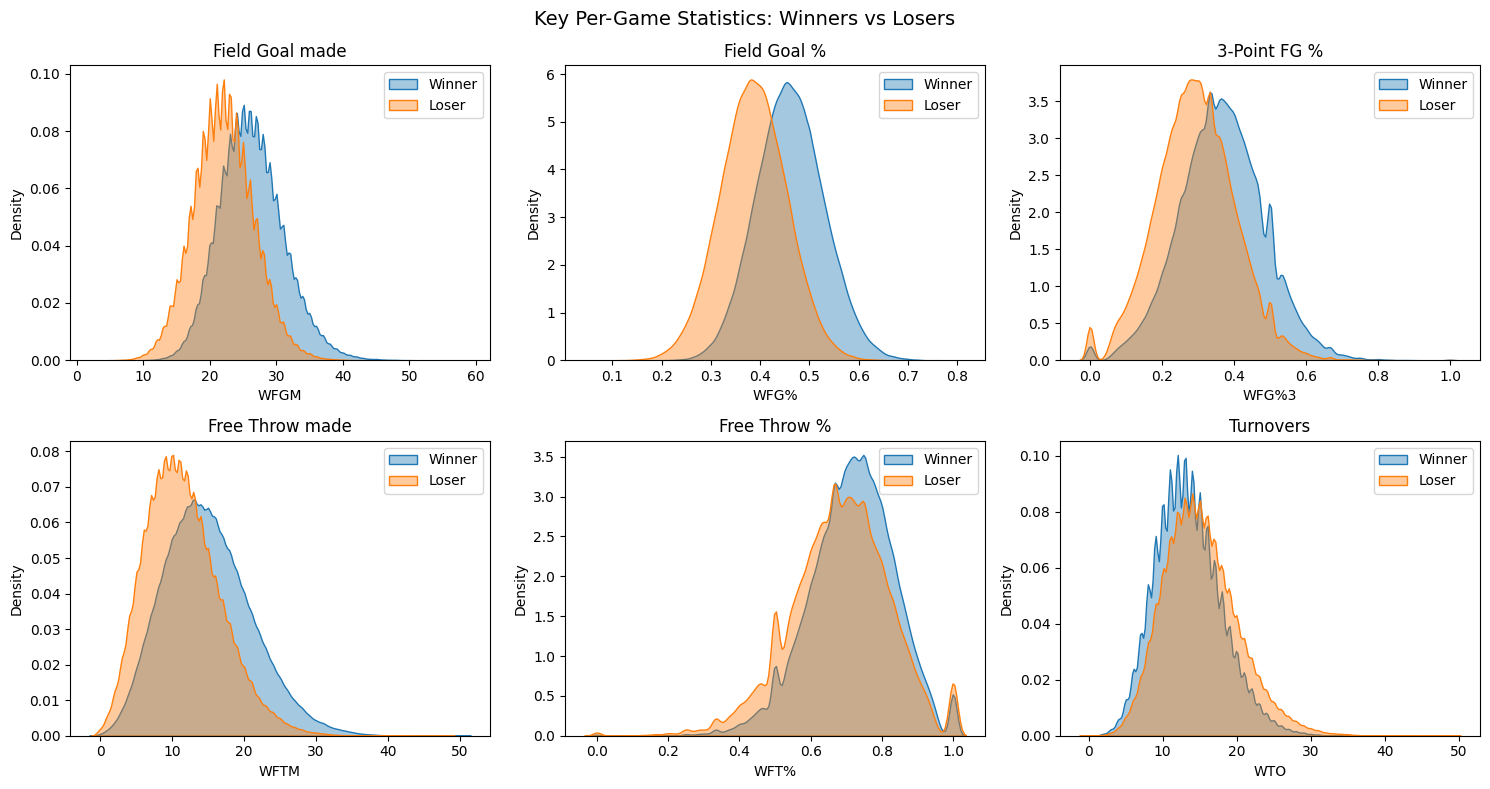

In [125]:
# comparing key per-game statistics for winners and losers
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
stats_pairs = [
    ('WFGM',    'LFGM',    'Field Goal made'),
    ('WFG%',    'LFG%',    'Field Goal %'),
    ('WFG%3',   'LFG%3',   '3-Point FG %'),
    ('WFTM',    'LFTM',    'Free Throw made'),
    ('WFT%',    'LFT%',    'Free Throw %'),
    ('WTO',     'LTO',     'Turnovers'),
]
for ax, (w_col, l_col, title) in zip(axes.flat, stats_pairs):
    seaborn.kdeplot(rr[w_col].dropna(), label='Winner', ax=ax, fill=True, alpha=0.4)
    seaborn.kdeplot(rr[l_col].dropna(), label='Loser',  ax=ax, fill=True, alpha=0.4)
    ax.set_title(title)
    ax.legend()
plt.suptitle('Key Per-Game Statistics: Winners vs Losers', fontsize=14)
plt.tight_layout()
plt.show()

## Data preparation
Our current dataset is on the POV of winners: WTeam is always the winning team, and this might not be ideal for our predictions (which are inherently ordered). We want our model to be independent on the order of teams: we will process our dataset so to contain T1_stats and T2_stats, where T1 and T2 order do not determine the vicory.

We will duplicate our dataset, each match will appear twice, and each team will be one time T1 and one time T2.

Given the high number of matches with NumOT > 0, we will also apply an adjustment to take into account more stats collected:

$$\text{adjusted stat} = \text{raw stat} \times \frac{40}{40 + 5 \times \text{NumOT}}$$

`NB:` 40 corresponds to match duration, 5 correspond to over-time duration (in mins).

Our objective is to output a probability of victory for each match in the tournament, given the features built from the regular season results.


In [126]:
def prepare_df(df: pd.DataFrame) -> pd.DataFrame:
    """Transform winning-POV dataset into T1-T2 teams, where each match appears twice."""
    df = df.copy()
    columns_to_adjust = ['WScore', 'LScore', 'WFGM', 'WFGA', 'WFGM3', 'WFGA3', 'WFTM', 'WFTA', 'WOR', 'WDR',
        'WAst', 'WTO', 'WStl', 'WBlk', 'WPF', 'LFGM', 'LFGA', 'LFGM3', 'LFGA3',
        'LFTM', 'LFTA', 'LOR', 'LDR', 'LAst', 'LTO', 'LStl', 'LBlk', 'LPF']
    adjust_coeff = 40 / (df["NumOT"] * 5 + 40)

    for c in columns_to_adjust:
        df[c] = df[c] * adjust_coeff
    
    df_2 = df.copy()

    df["Outcome"] = "win"
    df["ScoreDiff"] = df["WScore"] - df["LScore"]
    df_2["Outcome"] = "lose"
    df_2["ScoreDiff"] = df_2["LScore"] - df_2["WScore"]

    df.columns = [c.replace("W","T1").replace("L","T2") for c in df.columns]
    df["T1Loc"] = df["T1T2oc"] # The replace function didn't work for this :P
    df["T2Loc"] = df["T1Loc"].apply(lambda x: "A" if x =="H" else "H" if x == "A" else "N")
    df_2.columns = [c.replace("W","T2").replace("L","T1") for c in df_2.columns]
    df_2["T1Loc"] = df["T2Loc"]
    df_2["T2Loc"] = df["T1Loc"]
    df.drop(columns=["T1T2oc"], inplace=True)
    df_2.drop(columns=["T2T1oc"], inplace=True)
    final_df = pd.concat([df,df_2]).reset_index(drop=True)

    return final_df

In [127]:
regular_results = prepare_df(regular_results_df)
tourney_results = prepare_df(tourney_results_df)
seeds = seeds_df.copy() # just to be coherent with the naming

## Feature Engineering
### Easy features
First of all, let's build easy features that we already have. Let's introduce seed for each team, and compute their difference (which is more informative than the absolute seed itself).

Remember that we will use regular season's results to compute the features, and tourney results to train our model and make predictions!



In [128]:
seeds["int_seed"] = seeds_df["Seed"].map((lambda x: int(x[1:3])))
seeds.drop(columns=["Seed"], inplace=True)
seeds_T1 = seeds.copy().rename(columns={"TeamID": "T1TeamID", "int_seed": "T1Seed"}) # to ease the merge
seeds_T2 = seeds.copy().rename(columns={"TeamID": "T2TeamID", "int_seed": "T2Seed"}) # to ease the merge

Tournaments results might give us some insights on their correlation with regular season results. We didn't do this research and we will simply drop all the stats related to those games.   

**NOTE FOR SHARIQ, YOU MIGHT INVESTIGATE THIS**
- instead of dropping those columns, do plots or compare those averages with regular season averages.
- whatever you can think of

Lets see if the average performance stats changes between the regular game compared with the tournament?

**Does team perform better when stakes are high??**

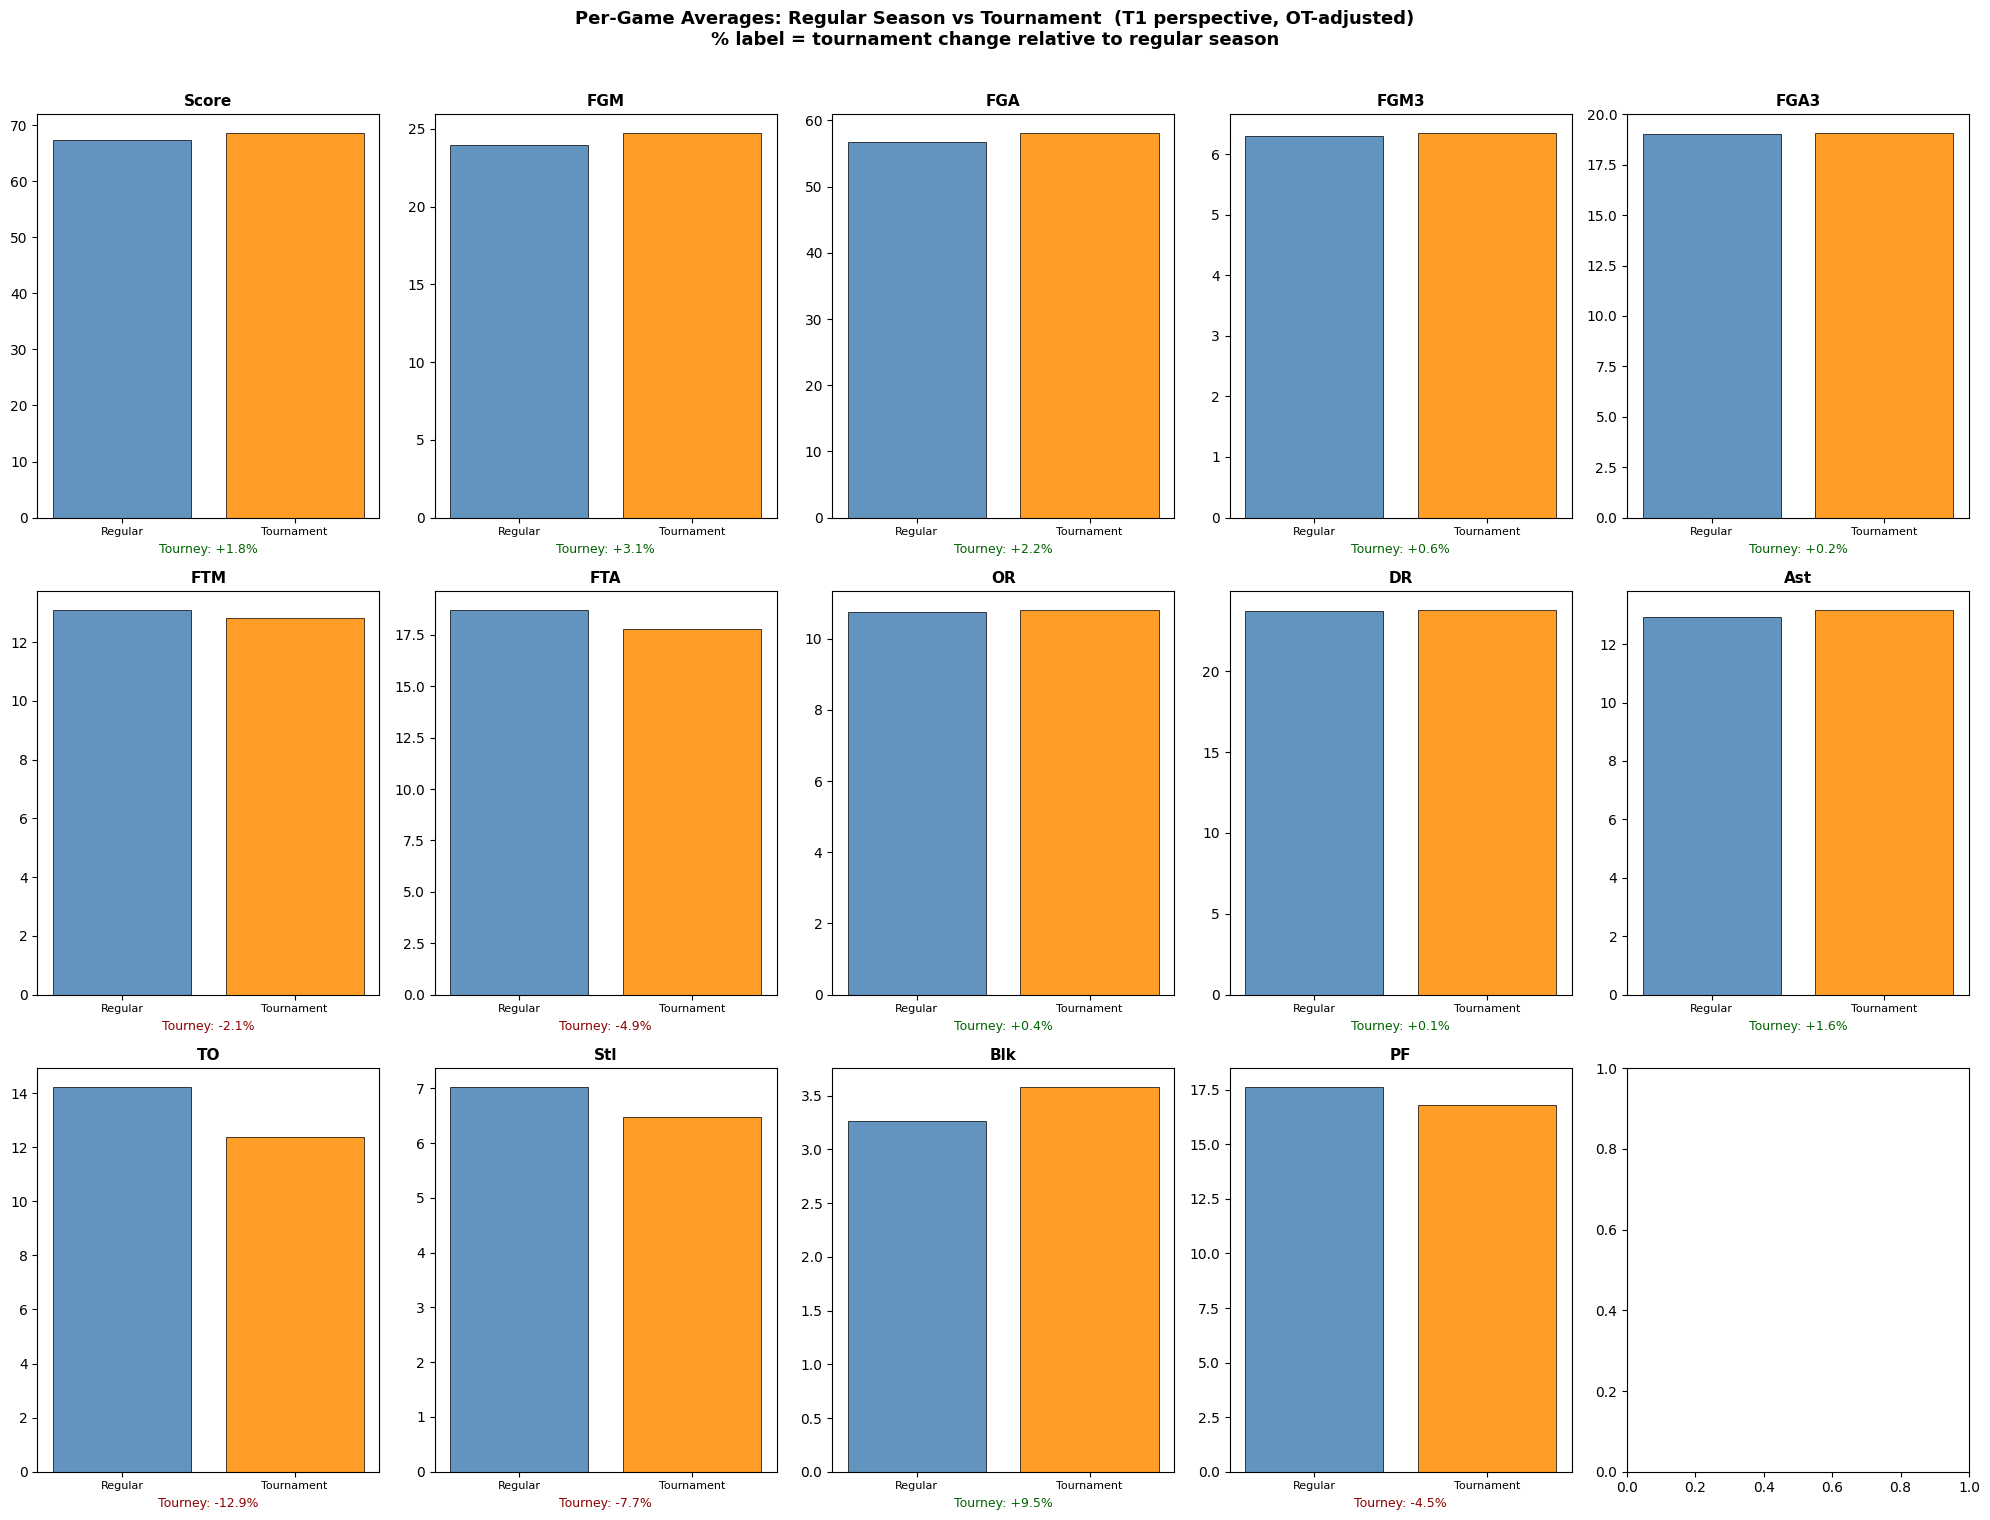

       Regular Season  Tournament  % Change
Score          67.314      68.558     1.847
FGM            23.968      24.706     3.081
FGA            56.825      58.058     2.169
FGM3            6.302       6.341     0.617
FGA3           19.017      19.056     0.206
FTM            13.077      12.805    -2.082
FTA            18.684      17.772    -4.880
OR             10.750      10.792     0.394
DR             23.733      23.761     0.120
Ast            12.943      13.154     1.628
TO             14.210      12.377   -12.902
Stl             7.018       6.477    -7.711
Blk             3.267       3.577     9.505
PF             17.605      16.814    -4.490


In [129]:
# Stats available in the prepared DataFrames (T1 perspective)
T1_STATS = ['T1Score','T1FGM','T1FGA','T1FGM3','T1FGA3',
            'T1FTM','T1FTA','T1OR','T1DR','T1Ast','T1TO','T1Stl','T1Blk','T1PF']
SHORT     = [s.replace('T1','') for s in T1_STATS]

reg_means   = regular_results[T1_STATS].mean()
tour_means  = tourney_results[T1_STATS].mean()
pct_changes = (tour_means - reg_means) / reg_means * 100

fig, axes = plt.subplots(3, 5, figsize=(20, 15))
axes = axes.flat

for ax, stat, short in zip(axes, T1_STATS, SHORT):
    vals   = [reg_means[stat], tour_means[stat]]
    labels = ['Regular', 'Tournament']
    colors = ['steelblue', 'darkorange']
    ax.bar(labels, vals, color=colors, alpha=0.85, edgecolor='black', linewidth=0.6)
    ax.set_title(short, fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', labelsize=8)
    pct = pct_changes[stat]
    color = 'darkgreen' if pct > 0 else 'darkred'
    ax.set_xlabel(f'Tourney: {pct:+.1f}%', fontsize=9, color=color)

for ax in list(axes)[len(T1_STATS):]:
    ax.set_visible(False)

fig.suptitle(
    'Per-Game Averages: Regular Season vs Tournament  (T1 perspective, OT-adjusted)\n'
    '% label = tournament change relative to regular season',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

# Summary table
summary = pd.DataFrame({'Regular Season': reg_means.values,
                        'Tournament':     tour_means.values,
                        '% Change':       pct_changes.values},
                       index=SHORT).round(3)
print(summary.to_string())


We can see that teams become more attacking as seen in increase in field goal, 3-pointers etc, at the same time the defence also increases as noted in increase of blocking.

Apart from average, does the distribution of the performance stats also changes??

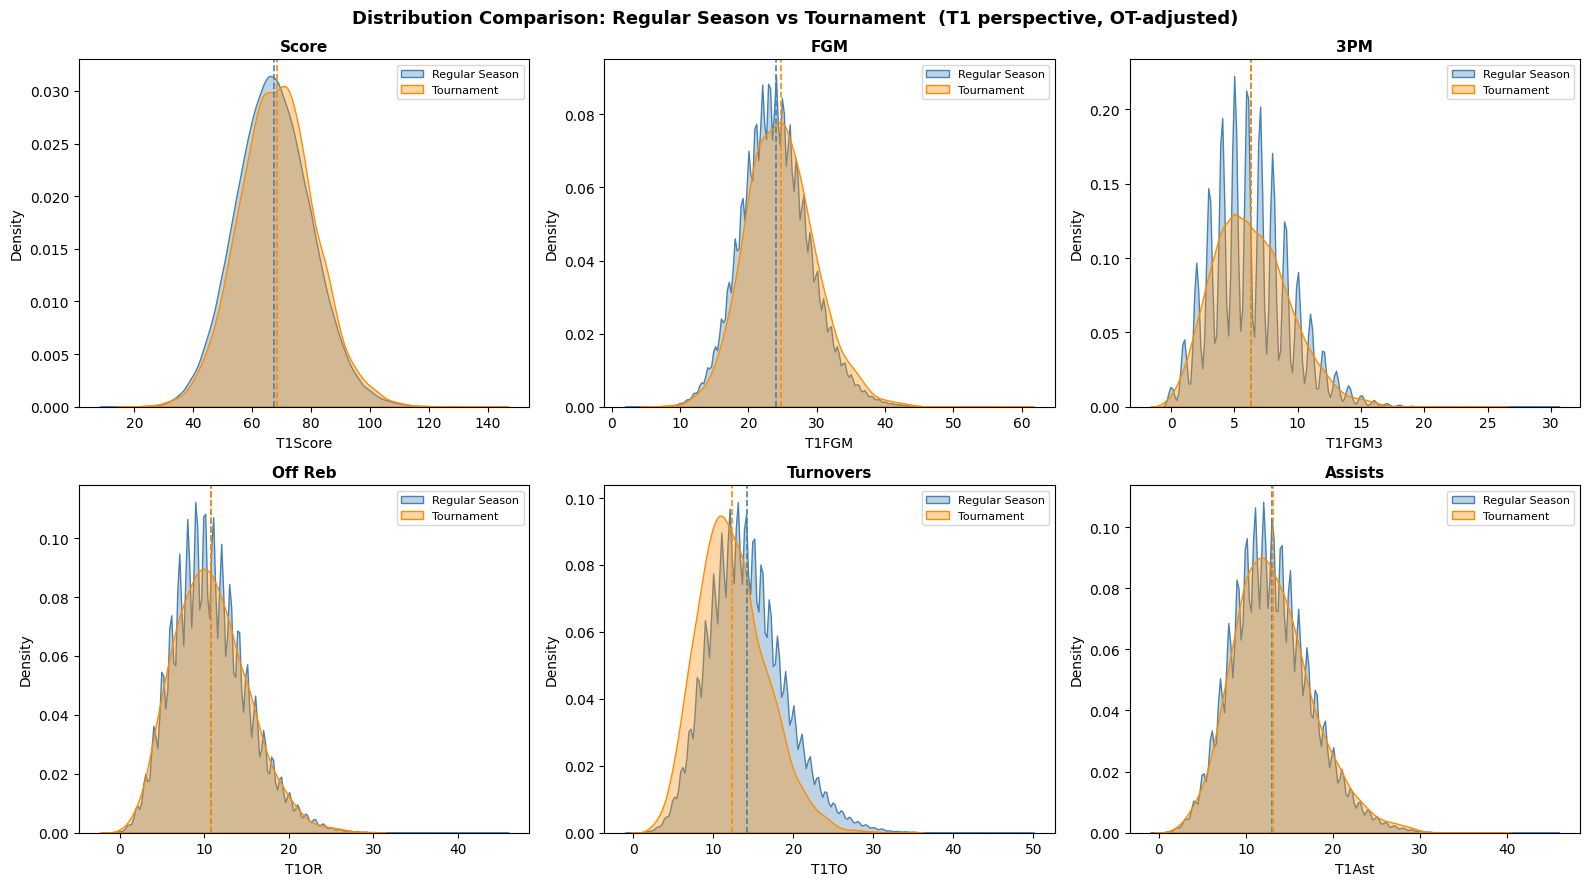

In [130]:
# Split by Category so Men's and Women's don't blur together
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

KDE_STATS = [('T1Score','Score'), ('T1FGM','FGM'),  ('T1FGM3','3PM'),
             ('T1OR','Off Reb'),  ('T1TO','Turnovers'),('T1Ast','Assists')]

for ax, (col, label) in zip(axes.flat, KDE_STATS):
    seaborn.kdeplot(regular_results[col].dropna(),
                    label='Regular Season', ax=ax, fill=True, alpha=0.35, color='steelblue')
    seaborn.kdeplot(tourney_results[col].dropna(),
                    label='Tournament',     ax=ax, fill=True, alpha=0.35, color='darkorange')
    # vertical means
    ax.axvline(regular_results[col].mean(), color='steelblue',   linestyle='--', lw=1.2)
    ax.axvline(tourney_results[col].mean(), color='darkorange',  linestyle='--', lw=1.2)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)

fig.suptitle('Distribution Comparison: Regular Season vs Tournament  (T1 perspective, OT-adjusted)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Which regular-season stats best predict tournament win rate?

For each (Season, Team) we compute their regular-season average stats and their tournament win rate (`Outcome == 'win'`). Pearson r tells us which features have the most predictive signal — useful for feature selection.

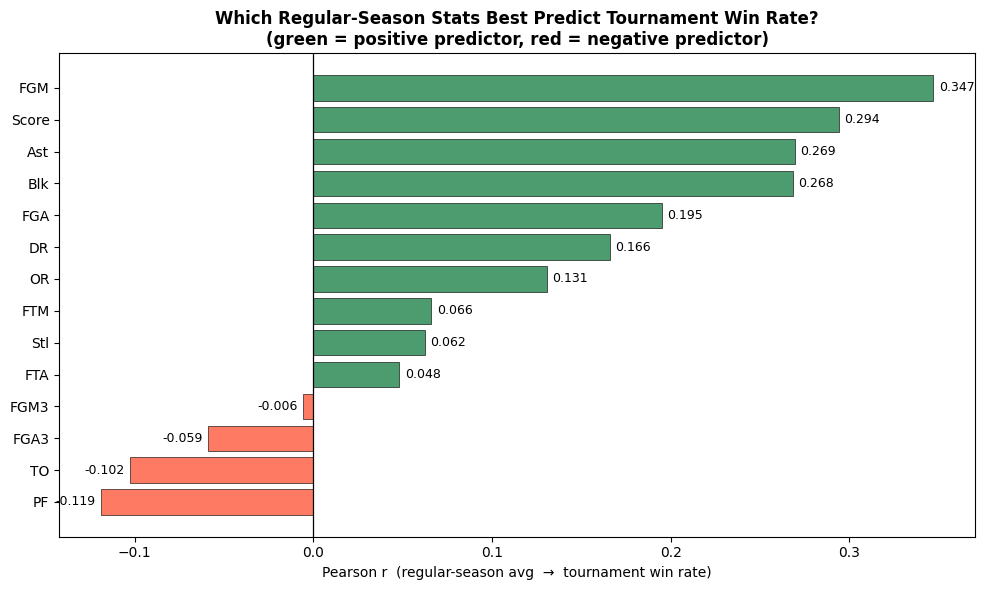


Top 5 POSITIVE predictors:
FGA      0.195318
Blk      0.268275
Ast      0.269356
Score    0.294024
FGM      0.347055

Top 5 NEGATIVE predictors:
PF     -0.118914
TO     -0.102329
FGA3   -0.059075
FGM3   -0.005642
FTA     0.048209


In [131]:
CORR_STATS = ['T1Score','T1FGM','T1FGA','T1FGM3','T1FGA3',
              'T1FTM','T1FTA','T1OR','T1DR','T1Ast','T1TO','T1Stl','T1Blk','T1PF']
SHORT_C    = [s.replace('T1','') for s in CORR_STATS]

# Regular-season averages per (Season, Team)
reg_avg_corr = (regular_results
                .groupby(['Season','T1TeamID','Category'])[CORR_STATS]
                .mean()
                .add_suffix('_reg'))

# Tournament win rate per (Season, Team)  — Outcome is 'win'/'lose'
tourney_results['_win'] = (tourney_results['Outcome'] == 'win').astype(int)
tour_winrate = (tourney_results
                .groupby(['Season','T1TeamID','Category'])
                .agg(WinRate=('_win','mean'))
                .reset_index()
                .set_index(['Season','T1TeamID','Category']))

merged_corr = tour_winrate.join(reg_avg_corr, how='inner')

corr_vals = (merged_corr
             .corr()['WinRate']
             .drop('WinRate')
             .rename(index=lambda s: s.replace('_reg','').replace('T1','')))
corr_vals = corr_vals.sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = ['seagreen' if v >= 0 else 'tomato' for v in corr_vals]
bars = ax.barh(corr_vals.index, corr_vals.values,
               color=bar_colors, edgecolor='black', linewidth=0.5, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.9)
for val, patch in zip(corr_vals.values, bars):
    ax.text(val + (0.003 if val >= 0 else -0.003),
            patch.get_y() + patch.get_height()/2,
            f'{val:.3f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=9)

ax.set_xlabel('Pearson r  (regular-season avg  →  tournament win rate)', fontsize=10)
ax.set_title('Which Regular-Season Stats Best Predict Tournament Win Rate?\n'
             '(green = positive predictor, red = negative predictor)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTop 5 POSITIVE predictors:")
print(corr_vals.tail(5).to_string())
print("\nTop 5 NEGATIVE predictors:")
print(corr_vals.head(5).to_string())


## Understanding the data drift across the years

Keeping an eye on the data drift is essential to understand the trend in the datset.

There are two types that matter here:

| Type | What changes | Example |
|---|---|---|
| **Covariate drift** | Distribution of input features `X` shifts | Teams shoot far more 3-pointers in 2025 than 2003 |
| **Concept drift** | Relationship between `X` and `y` shifts | 3PM used to be less predictive of winning; now it's more |


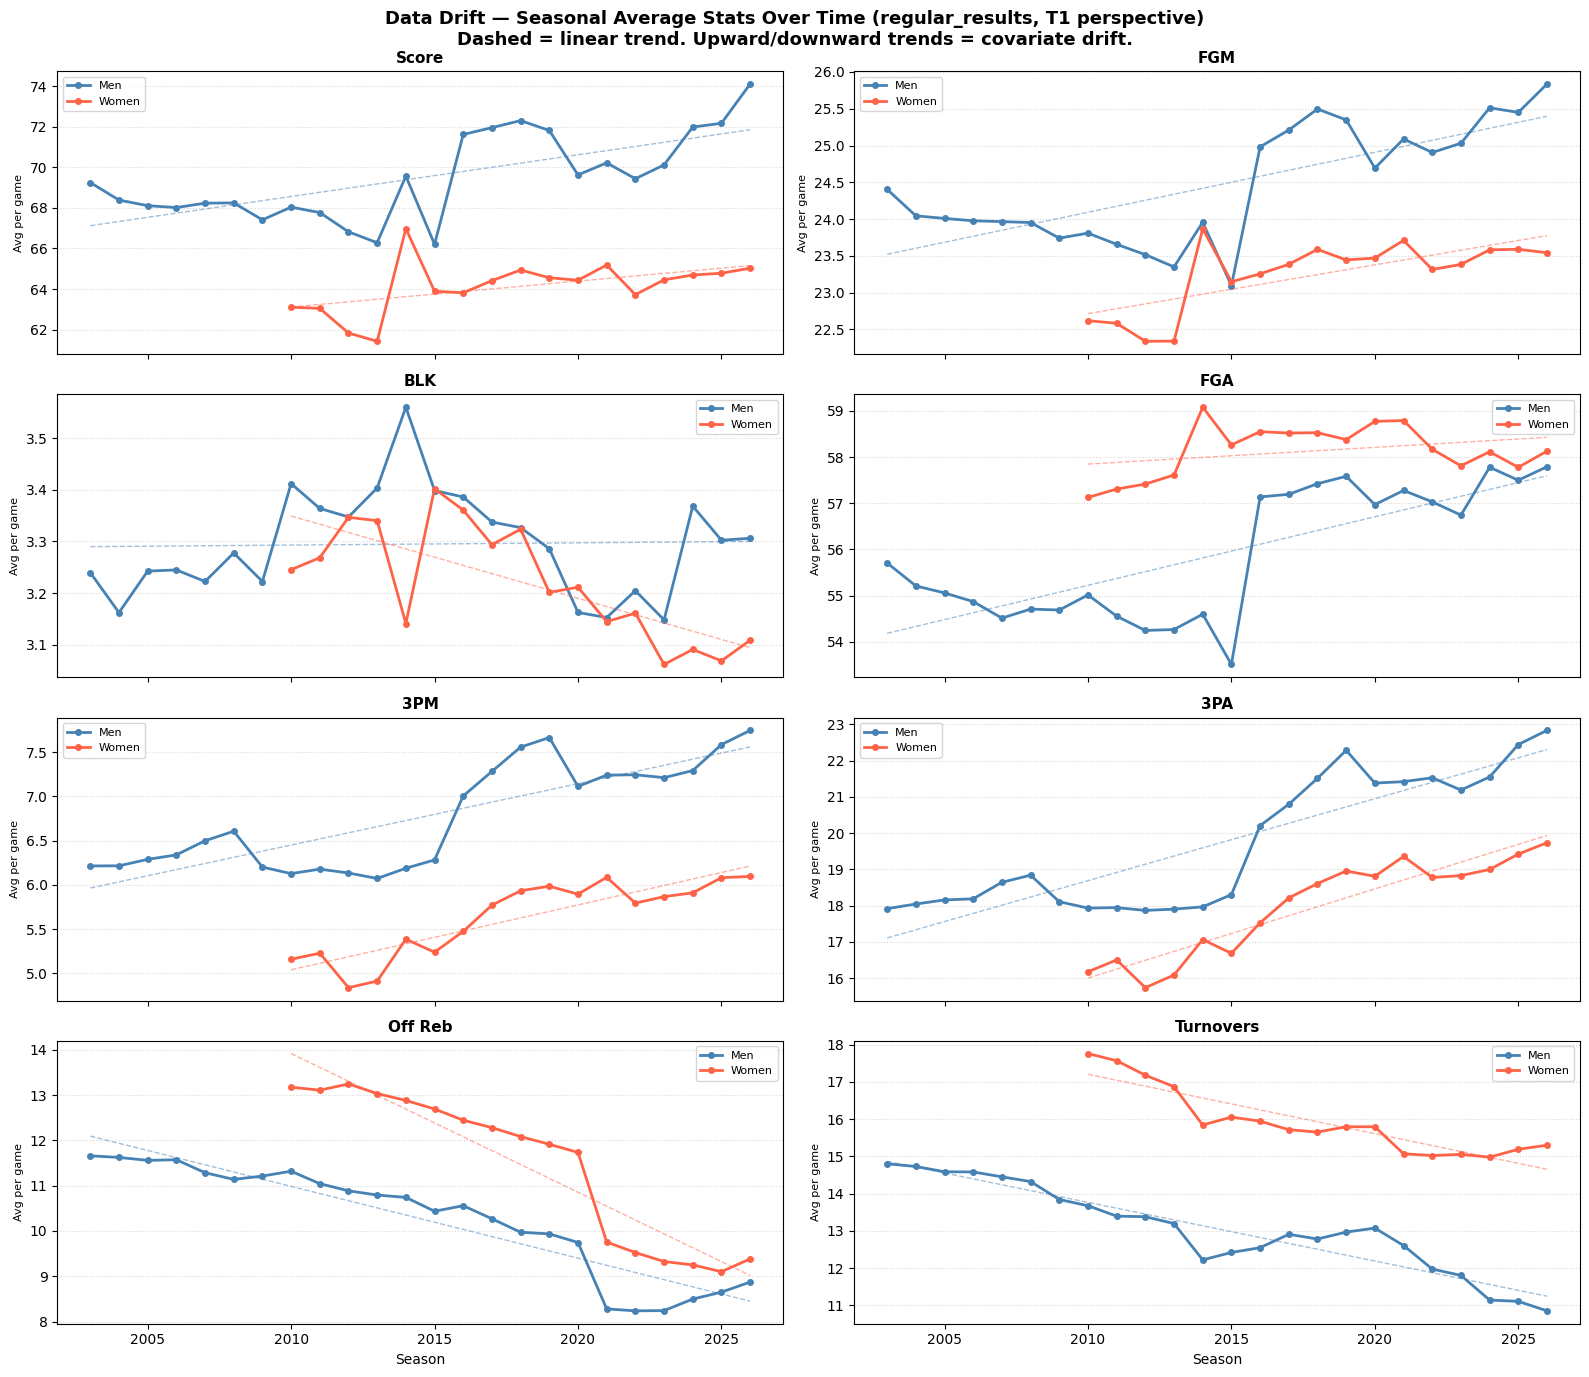

In [132]:
# ─── Covariate Drift: seasonal averages of key stats over time ──────────────
DRIFT_STATS = ['T1Score','T1FGM', 'T1Blk', 'T1FGA','T1FGM3', 'T1FGA3', 'T1OR', 'T1TO', 'T1Ast', 'T1Stl', 'T1PF']
SHORT_D     = ['Score','FGM','BLK', 'FGA', '3PM', '3PA', 'Off Reb', 'Turnovers', 'Assists', 'Steals', 'Fouls']

# Separate Men and Women — they have independent trends
cat_map    = {0: "Men", 1: "Women"}
cat_colors = {0: "steelblue", 1: "tomato"}

seasonal = (regular_results
            .groupby(['Season', 'Category'])[DRIFT_STATS]
            .mean()
            .reset_index())

fig, axes = plt.subplots(4, 2, figsize=(16, 14), sharex=True)

for ax, stat, short in zip(axes.flat, DRIFT_STATS, SHORT_D):
    for cat, grp in seasonal.groupby('Category'):
        grp = grp.sort_values('Season')
        ax.plot(grp['Season'], grp[stat],
                marker='o', markersize=4, lw=2,
                color=cat_colors[cat], label=cat_map[cat])
        # trend line
        import numpy as np
        m, b = np.polyfit(grp['Season'], grp[stat], 1)
        ax.plot(grp['Season'], m * grp['Season'] + b,
                '--', lw=1, color=cat_colors[cat], alpha=0.5)
    ax.set_title(short, fontsize=11, fontweight='bold')
    ax.set_ylabel('Avg per game', fontsize=8)
    ax.legend(fontsize=8)
    ax.grid(axis='y', linestyle=':', alpha=0.5)

axes.flat[-1].set_xlabel('Season', fontsize=10)
axes.flat[-2].set_xlabel('Season', fontsize=10)
fig.suptitle('Data Drift — Seasonal Average Stats Over Time (regular_results, T1 perspective)\n'
             'Dashed = linear trend. Upward/downward trends = covariate drift.',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## we can also plot per year change in a heatmap

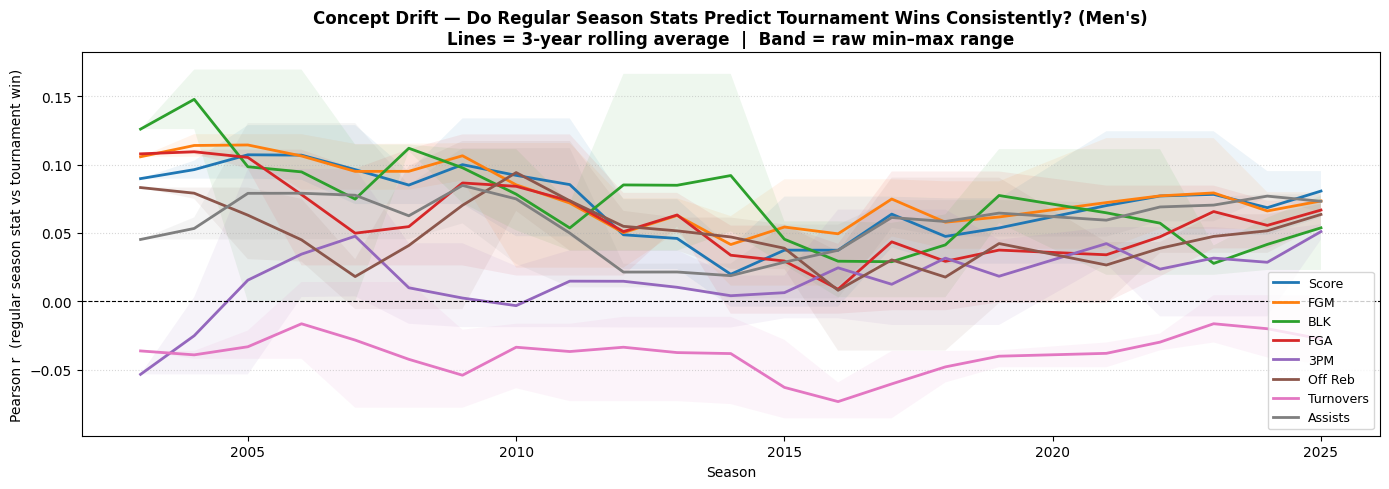

In [133]:
# ─── Concept Drift — does the stat→win relationship change across seasons? ───
# We check: is correlation between T1FGM3 (3PM) and winning growing over time?
# (The '3-point revolution' hypothesis)

CONCEPT_STATS = ['T1Score', 'T1FGM', 'T1Blk', 'T1FGA','T1FGM3', 'T1OR', 'T1TO', 'T1Ast']
SHORT_CONCEPT  = ['Score','FGM','BLK', 'FGA', '3PM', 'Off Reb', 'Turnovers', 'Assists']


reg_with_tourney_win = regular_results[regular_results['Category'] == 0].merge(
    tourney_results[tourney_results['Category'] == 0][['Season','T1TeamID','Outcome']]
    .rename(columns={'Outcome':'TourneyOutcome'}),
    on=['Season','T1TeamID'], how='inner')
reg_with_tourney_win['_win'] = (reg_with_tourney_win['TourneyOutcome'] == 'win').astype(int)



concept_corrs = []
for season, grp in reg_with_tourney_win.groupby('Season'):
    row = {'Season': season}
    for stat in CONCEPT_STATS:
        row[stat] = grp[stat].corr(grp['_win'])
    concept_corrs.append(row)

concept_df = pd.DataFrame(concept_corrs).set_index('Season')
concept_df.columns = SHORT_CONCEPT

fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('white'); ax.set_facecolor('white')

for col in concept_df.columns:
    smoothed = concept_df[col].rolling(3, min_periods=1).mean()
    raw      = concept_df[col]
    ax.plot(concept_df.index, smoothed, lw=2, label=col)
    ax.fill_between(concept_df.index, raw.rolling(3, min_periods=1).min(),
                    raw.rolling(3, min_periods=1).max(), alpha=0.08)

ax.axhline(0, color='black', lw=0.8, linestyle='--')
ax.set_xlabel('Season', fontsize=10)
ax.set_ylabel('Pearson r  (regular season stat vs tournament win)', fontsize=10)
ax.set_title("Concept Drift — Do Regular Season Stats Predict Tournament Wins Consistently? (Men's)\n"
             "Lines = 3-year rolling average  |  Band = raw min–max range",
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()


Now lets prepare the tourney data 

In [134]:
tourney_columns = ['Season', 'T1TeamID', 'T2TeamID', 'Outcome', 'ScoreDiff', 'Category']
tourney_results = tourney_results[tourney_columns]
tourney_results = tourney_results.merge(seeds_T1, 
                                       on=["Season", "T1TeamID"], 
                                       how="left").merge(seeds_T2, 
                                                         on=["Season", "T2TeamID"], 
                                                         how="left")
tourney_results["SeedDiff"] = tourney_results["T1Seed"] - tourney_results["T2Seed"]

### Basketball-specific per-game features:
Now we build basketball-specific features for each game!  

*Efficiency metrics*:
- Offensive efficiency  —> Points scored per offensive possession. (Score / Possession) * 100 
- Defensive efficiency  —> Points allowed per defensive possession. (Score / Possession) * 100 
- Net Efficiency        —> OE - DE
- Possessions           —> Number of times a team controls the ball and completes a sequence. FGA - OR + TO + (0.44 * FTA)  

*Shooting Metrics*:
- **Effective FG%** (eFG%)  —> (FGM + 0.5 * FGM3) / FGA (weights 3-pointers correctly)
- True Shooting% (TS%)  —> Score / (2 * (FGA + 0.44 * FTA))
- **Free throw rate**       —> FTM / FTA
- Draw fouls ability    —> FTA / FGA
- General shooting rates—> Made / Attempted

*Reboundings*:
- **Offensive rebounds** %  —> OR / (OR + Opp_DR)
- Defensive Rebound %   —> DR / (DR + Opp_OR)
- Total Rebound margin  —> OR - DR

*Team style*:
- **Turnover rate**           —> TO / Possessions
- Steal-to-Turnover       —> Stl / TO
- Assist-to-Turnover      —> Ast / TO  


**Stats** in bolds are **the four factors**: they explains most of the matches according to experts.  

Additionally, given the home-court advantage, we will compute an adjusted score that compensate for this with the data-driven values we computed during data exploration.

In [135]:
# home advantage is computed as (home_score_mean - away_score_mean)/2

LOCATION_ADJUSTED = {"H": -home_advantage,
                     "A": home_advantage,
                     "N": 0.0}

In [136]:
def compute_possessions(fga, or_, to, fta):
    return fga - or_ + to + 0.44 * fta

def build_per_game_features(df):
    df = df.copy()

    # adjusting the score based on location (additional feature)
    for team in ["T1", "T2"]:
        adj_points = df[f"{team}Loc"].map(LOCATION_ADJUSTED)
        df[f"{team}Score_adj"] = df[f"{team}Score"] + adj_points
    
        # computing possessions
        df[f"{team}Poss"] = compute_possessions(
            df[f"{team}FGA"], df[f"{team}OR"], df[f"{team}TO"], df[f"{team}FTA"]
        )

        # offensive efficiency
        df[f"{team}OE"] = (df[f"{team}Score_adj"] / df[f"{team}Poss"]) * 100

        # shooting metrics
        df[f"{team}eFG"] = (df[f"{team}FGM"] + 0.5 * df[f"{team}FGM3"]) / df[f"{team}FGA"] # 1 of the Four Factors
        df[f"{team}TS"] = df[f"{team}Score"] / (2 * (df[f"{team}FGA"] + 0.44 * df[f"{team}FTA"])) 
        df[f"{team}FT%"] = df[f"{team}FTM"] / df[f"{team}FTA"]
        df[f"{team}FTRate"] = df[f"{team}FTA"] / df[f"{team}FGA"] # 1 of the Four Factors
        df[f"{team}FG%"] = df[f"{team}FGM"] / df[f"{team}FGA"]
        df[f"{team}FG%3"] = df[f"{team}FGM3"] / df[f"{team}FGA3"]

        # team style
        df[f'{team}TORate']  = df[f'{team}TO']  / df[f'{team}Poss'] # 1 of the Four Factors
        df[f'{team}StlTORate'] = df[f'{team}Stl'] / (df[f'{team}TO'] + 1e-6)
        df[f'{team}AstTORate'] = df[f'{team}Ast'] / (df[f'{team}TO'] + 1e-6)

    # defensive efficiency
    df["T1DE"] = (df["T2Score_adj"] / df["T2Poss"]) * 100
    df["T2DE"] = (df["T1Score_adj"] / df["T1Poss"]) * 100

    # net efficiency
    df["T1NE"] = df["T1OE"] - df["T1DE"]
    df["T2NE"] = df["T2OE"] - df["T2DE"]

    # reboundings
    df['T1ORRate'] = df['T1OR'] / (df['T1OR'] + df['T2DR']) # 1 of the Four Factors
    df['T1DRRate'] = df['T1DR'] / (df['T1DR'] + df['T2OR']) # 1 of the Four Factors
    df['T2ORRate'] = df['T2OR'] / (df['T2OR'] + df['T1DR'])
    df['T2DRRate'] = df['T2DR'] / (df['T2DR'] + df['T1OR'])

    return df

In [137]:
regular_results_per_game_stats = build_per_game_features(regular_results)

## Elo Rating

The **Elo rating** is a method for quantifying the relative skill of teams. Each team starts at 1500 (hyperparameter) and is updated after every game:

$$r_{\text{new}} = r_{\text{old}} + K \cdot \text{MoV} \cdot (o - e)$$

- $o \in \{0, 1\}$: actual outcome  
- $e$: expected win probability derived from the rating gap  
- $K = 32$: update speed (hyperparameter)
- **MoV** (Margin of Victory multiplier): $\log(|\Delta\text{score}| + 1)$ — rewards convincing wins  

At the start of each new season ratings are **regressed 40 % toward the mean** to account for roster changes. The end-of-season rating is carried into the tournament as a feature.

In [138]:
INITIAL_ELO = 1500
K = 32
HOME_ADVANTAGE_ELO = 100   # ELO points bonus for home team; a team playing home is stronger than expected.
SEASON_REGRESSION = 0.4
MEAN_ELO = 1500

In [139]:
def expected_score(r1, r2, t1_loc):
    adj = {'H': HOME_ADVANTAGE_ELO, 'A': -HOME_ADVANTAGE_ELO, 'N': 0}[t1_loc]
    return 1 / (1 + 10 ** (-(r1 - r2 + adj) / 400))
 
def mov_multiplier(point_diff, elo_diff):
    """mov multiplier according to fivethirthyeight"""
    mov = np.log(abs(point_diff) + 1)
    return mov

In [140]:
def compute_elo(df):
    """
    Compute pre-game ELO ratings for every game.
    Returns df with T1_Elo_Before, T2_Elo_Before columns.
    Also returns final ELO dict per (Season, TeamID) for use as tournament features.
    """
    df = df.sort_values(['Season', 'DayNum']).reset_index(drop=True).copy()
    elo = {}
    season_end_elo = {}   # {(season, team_id): elo}
 
    t1_elo_before, t2_elo_before = [], []
    current_season = None
 
    for _, row in df.iterrows():
        t1, t2 = int(row['T1TeamID']), int(row['T2TeamID'])
        season = row['Season']
 
        # season transition: save end-of-season ratings, then regress to mean
        if season != current_season:
            if current_season is not None:
                for tid, rating in elo.items():
                    season_end_elo[(current_season, tid)] = rating
                    elo[tid] = MEAN_ELO + (rating - MEAN_ELO) * (1 - SEASON_REGRESSION)
            current_season = season
 
        r1 = elo.get(t1, INITIAL_ELO)
        r2 = elo.get(t2, INITIAL_ELO)
 
        t1_elo_before.append(r1)
        t2_elo_before.append(r2)
 
        e1 = expected_score(r1, r2, row['T1Loc'])
        e2 = 1 - e1
 
        o1 = 1 if row['Outcome'] == 'win' else 0
        o2 = 1 - o1
 
        winner_elo_diff = (r1 - r2) if o1 == 1 else (r2 - r1)
        multiplier = mov_multiplier(row['ScoreDiff'], winner_elo_diff)
 
        elo[t1] = r1 + K * multiplier * (o1 - e1)
        elo[t2] = r2 + K * multiplier * (o2 - e2)
 
    # save last season: this will be used as feature
    for tid, rating in elo.items():
        season_end_elo[(current_season, tid)] = rating
 
    df['T1_Elo_Before'] = t1_elo_before
    df['T2_Elo_Before'] = t2_elo_before
 
    return df, season_end_elo

In [141]:
regular_results_per_game_stats_with_elo, season_end_elo = compute_elo(regular_results_per_game_stats)

### Aggregate features per season

We now aggregate all per-game statistics to obtain one row per *(Season, TeamID)*. This gives us the **average performance** of each team throughout the regular season against the average opponent, which is what we will use as input features for the tournament model (stats beginning with T1). Additionally, we will also have the average performance of an opponent against the team under analysis, which will be also used as input features (stats beginning with T2).

Two types of aggregated columns are produced:
- **Raw averages** — mean of each per-game stat (e.g. `T1_avg_Score`, `T1_avg_eFG`, `T1_Opponent_avg_Score`, `T1_Opponent_avg_eFG`)
- **Diff stats** — difference between T1 and T2 metrics within each game, then averaged (e.g. `T1_avg_NEDiff = mean(T1NE - T2NE)`)

In [142]:
DIFF_STATS = [ # stats for which we will compute differences
    'OE', 'DE', 'NE',
    'eFG', 'TS', 
    'ORRate', 'DRRate',
    'TORate', 'FTRate',
    'AstTORate', 'StlTORate', 
    'Score_adj'
]

AVG_STATS = [ # stats for which we will compute the average
    'T1Score', 'T2Score',
    'NumOT', 'T1FGM', 'T1FGA', 'T1FGM3', 'T1FGA3', 'T1FTM', 'T1FTA', 'T1OR',
    'T1DR', 'T1Ast', 'T1TO', 'T1Stl', 'T1Blk', 'T1PF', 'T2FGM', 'T2FGA',
    'T2FGM3', 'T2FGA3', 'T2FTM', 'T2FTA', 'T2OR', 'T2DR', 'T2Ast', 'T2TO',
    'T2Stl', 'T2Blk', 'T2PF', 'ScoreDiff', 'T1Score_adj', 'T1Poss', 'T1OE', 'T1eFG', 'T1TS', 'T1FT%',
    'T1FDA', 'T1FG%', 'T1FG%3', 'T1TORate', 'T1StlTORate', 'T1AstTORate',
    'T2Score_adj', 'T2Poss', 'T2OE', 'T2eFG', 'T2TS', 'T2FT%', 'T2FDA',
    'T2FG%', 'T2FG%3', 'T2TORate', 'T2StlTORate', 'T2AstTORate', 'T1DE',
    'T2DE', 'T1NE', 'T2NE', 'T1ORRate', 'T1DRRate', 'T2ORRate', 'T2DRRate']

def compute_diff_stats(df):
    """
    Compute per-game diff stats.
    """
    df = df.copy()
    for feature in DIFF_STATS:
        df[f"T1{feature}Diff"] = df[f"T1{feature}"] - df[f"T2{feature}"] # we compute the diff featuers in the POV of T1.

    return df

def aggregate_team_season(df):
    """
    Aggregate per-game stats to one row per (Season, TeamID).
    """
    columns_to_average = list(set(df.columns) - {'Category','DayNum','Outcome','Season','T1Loc','T1TeamID','T2Loc','T2TeamID'})
    df = df.copy().groupby(["Season", "T1TeamID"])[columns_to_average].mean().reset_index()
    return df
    
def create_features(results_df, tourney_df):
    df_T1 = results_df.copy()
    df_T2 = results_df.copy()
    features_df = tourney_df.copy()
    df_T1.columns = ["T1_avg_" + c.replace("T1","").replace("T2","Opponent_") for c in df_T1.columns]
    df_T1.rename(columns={"T1_avg_Season": "Season", "T1_avg_TeamID": "T1TeamID"}, inplace=True)
    df_T2.columns = ["T2_avg_" + c.replace("T1","").replace("T2","Opponent_") for c in df_T2.columns]
    df_T2.rename(columns={"T2_avg_Season": "Season", "T2_avg_TeamID": "T2TeamID"}, inplace=True)
    
    features_df = pd.merge(features_df, df_T1, on=["Season", "T1TeamID"], how="left")
    features_df = pd.merge(features_df, df_T2, on=["Season", "T2TeamID"], how="left")

    return features_df


In [143]:
tourney_results_with_features = create_features(
    aggregate_team_season(
        compute_diff_stats(regular_results_per_game_stats_with_elo)
        ), tourney_results)

For the Elo feature, we do not want to use the average throughout the season, but the Elo at the end of the season.  
Let's correct Elo values to the last of the regular season, and let's compute the diff and the elo_win_probability as features!

In [144]:
tourney_results_with_features["T1_Elo"] = tourney_results_with_features.apply(
        lambda r: season_end_elo.get((r['Season'], int(r['T1TeamID'])), INITIAL_ELO), axis=1
    )

tourney_results_with_features["T2_Elo"] = tourney_results_with_features.apply(
        lambda r: season_end_elo.get((r['Season'], int(r['T2TeamID'])), INITIAL_ELO), axis=1
    )

tourney_results_with_features["EloDiff"] = tourney_results_with_features["T1_Elo"] - tourney_results_with_features["T2_Elo"]
tourney_results_with_features['elo_win_prob'] = 1 / (1 + 10 ** (-tourney_results_with_features['EloDiff'] / 400))

tourney_results_with_features.drop(columns=[
    'T1_avg__Elo_Before',
    'T1_avg_Opponent__Elo_Before',
    'T2_avg__Elo_Before',
    'T2_avg_Opponent__Elo_Before',],
    inplace=True) # we do not need those features!

### LateSeasonRank regression for Women
We have ordinal rankings for Men competition only. We will try to do regression on this feature for Men and compute it for Women.  

Let's extract the mean of the last 5 games and use it as a feature explaining the late season ranking (a team might get better/worse throughout a season!)

In [145]:
grouped_ordinals = M_massey_ordinals_df.groupby(["Season","TeamID","RankingDayNum"])["OrdinalRank"].mean().reset_index()

M_ordinals = pd.DataFrame(columns=["Season","TeamID","LateSeasonRank"])
seasons, team_ids, late_season_ranks = [],[],[]
for season in grouped_ordinals["Season"].unique():
    for team_id in grouped_ordinals[grouped_ordinals["Season"]==season]["TeamID"].unique():
        seasons.append(season)
        team_ids.append(team_id)
        late_season_ranks.append(
            grouped_ordinals[(grouped_ordinals["Season"]==season) & (grouped_ordinals["TeamID"]==team_id)]["OrdinalRank"][-5:].mean()
        )

M_ordinals["Season"] = seasons
M_ordinals["TeamID"] = team_ids
M_ordinals["LateSeasonRank"] = late_season_ranks

M_ordinals

,Season,TeamID,LateSeasonRank
0,2003,1102,158.939583
1,2003,1103,166.284848
2,2003,1104,34.591098
3,2003,1105,306.896780
4,2003,1106,247.079924
...,...,...,...
8351,2026,1477,297.716755
8352,2026,1478,297.588690
8353,2026,1479,289.077499
8354,2026,1480,291.901605


Let's select some features for regressing LateSeasonRank (Four Factors!)

In [146]:
features_for_regression = [
'T1Seed',
'T1_avg_Score',
# 'T1_avg_Blk',
# 'T1_avg_AstTORate',
'T1_avg_FTRate',
# 'T1_avg_FTM',
# 'T1_avg_Stl',
# 'T1_avg_FG%3',
'T1_avg_eFG',
# 'T1_avg_FGM3',
'T1_avg_DRRate',
# 'T1_avg_Score_adj',
'T1_avg_NE',
# 'T1_avg_NumOT',
# 'T1_avg_Ast',
# 'T1_avg_OR',
# 'T1_avg_OE',
# 'T1_avg_FGA3',
# 'T1_avg_Poss',
# 'T1_avg_PF',
# 'T1_avg_FTA',
# 'T1_avg_FT%',
# 'T1_avg_FGA',
# 'T1_avg_TS',
# 'T1_avg_StlTORate',
'T1_avg_TORate',
# 'T1_avg_DE',
# 'T1_avg_FG%',
# 'T1_avg_FGM',
'T1_avg_ORRate',
'T1_Elo']

In [147]:
tourney_results_with_regression_features = tourney_results_with_features[['Season','T1TeamID'] + features_for_regression]

In [148]:
# tourney_results_with_regression_features has one row per match per team.
# since we only kept T1 features, matches for the same team are duplicates. we will drop them.

M_tourney_results_with_regression_features = tourney_results_with_regression_features.loc[tourney_results_with_features["Category"]==0].drop_duplicates()
W_tourney_results_with_regression_features = tourney_results_with_regression_features.loc[tourney_results_with_features["Category"]==1].drop_duplicates()
M_tourney_results_with_regression_features = M_tourney_results_with_regression_features.merge(M_ordinals.rename(columns={"TeamID": "T1TeamID", "LateSeasonRank": "T1LateSeasonRank"}), 
                                       on=["Season", "T1TeamID"], 
                                       how="left")


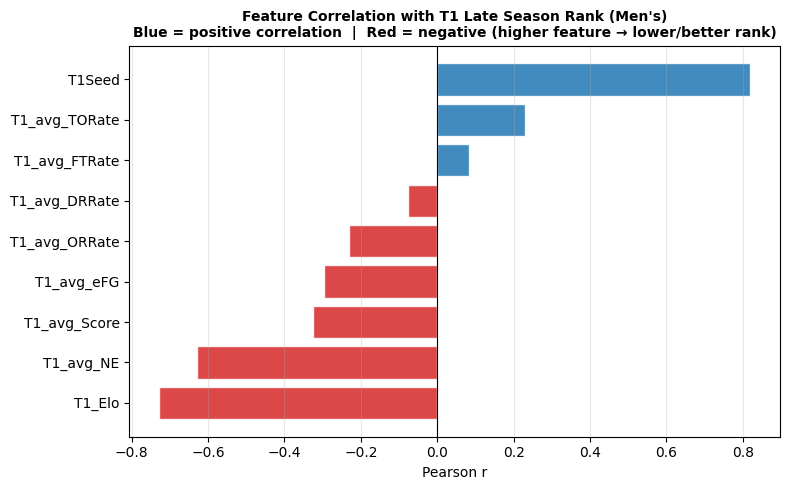

In [149]:
# Pearson correlation of each feature with T1LateSeasonRank (Men's only)
feat_cols = [c for c in M_tourney_results_with_regression_features.columns
             if c not in ('Season', 'T1TeamID', 'T1LateSeasonRank')]

df_corr = M_tourney_results_with_regression_features[feat_cols + ['T1LateSeasonRank']].dropna()
corrs   = df_corr[feat_cols].corrwith(df_corr['T1LateSeasonRank']).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('white'); ax.set_facecolor('white')
colors = ['#d62728' if v < 0 else '#1f77b4' for v in corrs]
ax.barh(corrs.index, corrs.values, color=colors, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Pearson r')
ax.set_title("Feature Correlation with T1 Late Season Rank (Men's)\n"
             "Blue = positive correlation  |  Red = negative (higher feature → lower/better rank)",
             fontsize=10, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

### Model for regression
We use a simple Ridge regression since it tends to work quite good.

**NOTE FOR SHARIQ, YOU MIGHT INVESTIGATE THIS**
- try other models, looking at the scores.mean() produced. the lower, the better! additionally, look at the feature distribution below. the closer men's and women's distribution are, the better it is. To be honest, i am already satisfied with this model but if you have any idea just try. BE CAREFUL WITH OVERFITTING! EXTRA COMPLEX MODELS/FEATURES ARE NOT NEEDED (OCCAM'S RAZOR) 

In [150]:
from sklearn.linear_model import Ridge
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

regression_target = "T1LateSeasonRank"

X_train = M_tourney_results_with_regression_features.copy().drop(columns=regression_target)
y_train = M_tourney_results_with_regression_features[regression_target]

model_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('reg', Ridge(alpha=1.0)),
])
model_ridge_log = TransformedTargetRegressor(regressor=model_ridge, func=np.log, inverse_func=np.exp)
model_ridge_log.fit(X_train, y_train)

X_pred = W_tourney_results_with_regression_features.copy().drop_duplicates()
y_pred_ridge = model_ridge_log.predict(X_pred).clip(min=min(y_train), max=max(y_train))

scores_ridge = cross_val_score(model_ridge_log, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
print(f"Ridge CV RMSE: {-scores_ridge.mean():.2f}")

Ridge CV RMSE: 15.51


#### Ridge Regression — comparison with Men Late Season Rank

The distribution of predicted Women Late Season Rank (via Ridge) vs the actual Men's distribution. The closer they are, the better the regression is working.

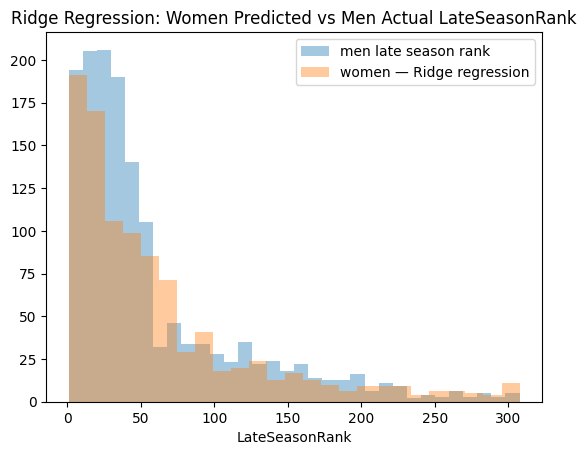

In [151]:
seaborn.distplot(y_train, label="men late season rank", kde=False)
seaborn.distplot(y_pred_ridge, label="women — Ridge regression", kde=False)
plt.legend()
plt.title("Ridge Regression: Women Predicted vs Men Actual LateSeasonRank")
plt.xlabel("LateSeasonRank")
plt.show()

In [152]:
from sklearn.ensemble import GradientBoostingRegressor

regression_target = "T1LateSeasonRank"

model_gboost = GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42)
model_gboost_log = TransformedTargetRegressor(regressor=model_gboost, func=np.log, inverse_func=np.exp)
model_gboost_log.fit(X_train, y_train)

X_pred = W_tourney_results_with_regression_features.copy().drop_duplicates()
y_pred_gboost = model_gboost_log.predict(X_pred).clip(min=min(y_train), max=max(y_train))
y_pred = y_pred_gboost  # use GBoost as final prediction

scores_gboost = cross_val_score(model_gboost_log, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
print(f"GradientBoost CV RMSE: {-scores_gboost.mean():.2f}")

# Model comparison summary
print(f"\n--- Regression Model Comparison (CV RMSE, lower is better) ---")
print(f"Ridge:                 {-scores_ridge.mean():.2f}")
print(f"GradientBoosting:      {-scores_gboost.mean():.2f}")

GradientBoost CV RMSE: 12.65

--- Regression Model Comparison (CV RMSE, lower is better) ---
Ridge:                 15.51
GradientBoosting:      12.65


#### Gradient Boost — comparison with Men Late Season Rank

The distribution of predicted Women Late Season Rank (via Gradient Boosting) vs Men's actual ranks.

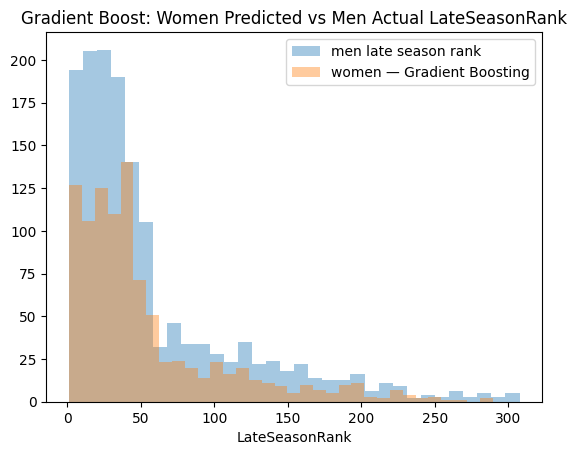

In [153]:
seaborn.distplot(y_train, label="men late season rank", kde=False)
seaborn.distplot(y_pred_gboost, label="women — Gradient Boosting", kde=False)
plt.legend()
plt.title("Gradient Boost: Women Predicted vs Men Actual LateSeasonRank")
plt.xlabel("LateSeasonRank")
plt.show()

Let's add the predicted late season rank

In [154]:
W_tourney_results_with_regression_features[regression_target] = y_pred

In [155]:
ordinals_regression_features = pd.concat([
    M_tourney_results_with_regression_features,
    W_tourney_results_with_regression_features
    ])[["Season","T1TeamID","T1LateSeasonRank"]]

ordinals_regression_features_T1 = ordinals_regression_features.copy()
ordinals_regression_features_T2 = ordinals_regression_features.copy()
ordinals_regression_features_T2.columns = [col.replace("T1", "T2") for col in ordinals_regression_features_T1.columns]

tourney_results_with_features = tourney_results_with_features.merge(ordinals_regression_features_T1,  
                                    on=["Season", "T1TeamID"], how="left").merge(ordinals_regression_features_T2,  
                                    on=["Season", "T2TeamID"], how="left")

tourney_results_with_features["LateSeasonRankDiff"] = tourney_results_with_features["T1LateSeasonRank"] - tourney_results_with_features["T2LateSeasonRank"]

### Features selection:
We build several features to use for predicting the outcomes. Which one are the best?

In [156]:
all_features =  [
# 'Season',
# 'T1TeamID',
# 'T2TeamID',
# 'Outcome',
# 'ScoreDiff',
'Category',
'T1Seed',
'T2Seed',
'SeedDiff',
'T1LateSeasonRank',
'T2LateSeasonRank',
'LateSeasonRankDiff',
'T1_avg_FT%',
'T1_avg_TORate',
'T1_avg_Opponent_ORRate',
'T1_avg_FGA3',
'T1_avg_Opponent_FGM3',
'T1_avg_Opponent_Score',
'T1_avg_Opponent_Blk',
'T1_avg_FTM',
'T1_avg_ORRate',
'T1_avg_Opponent_Poss',
'T1_avg_FTRate',
'T1_avg_PF',
'T1_avg_eFGDiff',
'T1_avg_Opponent_NE',
'T1_avg_Poss',
'T1_avg_Opponent_TO',
'T1_avg_Opponent_DE',
'T1_avg_Opponent_FTM',
'T1_avg_Opponent_StlTORate',
'T1_avg_Opponent_DRRate',
'T1_avg_eFG',
'T1_avg_Opponent_OR',
'T1_avg_TSDiff',
'T1_avg_Opponent_OE',
# 'T1_avg_NumOT',
'T1_avg_Opponent_eFG',
'T1_avg_Opponent_FTRate',
'T1_avg_FGA',
'T1_avg_Opponent_FG%',
'T1_avg_FGM',
'T1_avg_FGM3',
'T1_avg_TORateDiff',
'T1_avg_Opponent_DR',
'T1_avg_Opponent_FGM',
'T1_avg_NEDiff',
'T1_avg_Opponent_FTA',
'T1_avg_TO',
'T1_avg_Opponent_Ast',
'T1_avg_StlTORate',
'T1_avg_OE',
'T1_avg_FG%3',
'T1_avg_AstTORate',
'T1_avg_AstTORateDiff',
'T1_avg_Score_adj',
'T1_avg_FTA',
'T1_avg_Opponent_TORate',
'T1_avg_Stl',
'T1_avg_Opponent_Stl',
'T1_avg_Opponent_FG%3',
'T1_avg_DR',
'T1_avg_ORRateDiff',
'T1_avg_Score',
'T1_avg_Opponent_FGA',
'T1_avg_Opponent_FT%',
'T1_avg_Score_adjDiff',
'T1_avg_OR',
'T1_avg_Opponent_AstTORate',
'T1_avg_OEDiff',
'T1_avg_DRRateDiff',
'T1_avg_ScoreDiff',
'T1_avg_NE',
'T1_avg_StlTORateDiff',
'T1_avg_Opponent_TS',
'T1_avg_FG%',
'T1_avg_Opponent_Score_adj',
'T1_avg_DRRate',
'T1_avg_Blk',
'T1_avg_Opponent_PF',
'T1_avg_Opponent_FGA3',
'T1_avg_FTRateDiff',
'T1_avg_DEDiff',
'T1_avg_Ast',
'T1_avg_DE',
'T1_avg_TS',
'T2_avg_FT%',
'T2_avg_TORate',
'T2_avg_Opponent_ORRate',
'T2_avg_FGA3',
'T2_avg_Opponent_FGM3',
'T2_avg_Opponent_Score',
'T2_avg_Opponent_Blk',
'T2_avg_FTM',
'T2_avg_ORRate',
'T2_avg_Opponent_Poss',
'T2_avg_FTRate',
'T2_avg_PF',
'T2_avg_eFGDiff',
'T2_avg_Opponent_NE',
'T2_avg_Poss',
'T2_avg_Opponent_TO',
'T2_avg_Opponent_DE',
'T2_avg_Opponent_FTM',
'T2_avg_Opponent_StlTORate',
'T2_avg_Opponent_DRRate',
'T2_avg_eFG',
'T2_avg_Opponent_OR',
'T2_avg_TSDiff',
'T2_avg_Opponent_OE',
# 'T2_avg_NumOT',
'T2_avg_Opponent_eFG',
'T2_avg_Opponent_FTRate',
'T2_avg_FGA',
'T2_avg_Opponent_FG%',
'T2_avg_FGM',
'T2_avg_FGM3',
'T2_avg_TORateDiff',
'T2_avg_Opponent_DR',
'T2_avg_Opponent_FGM',
'T2_avg_NEDiff',
'T2_avg_Opponent_FTA',
'T2_avg_TO',
'T2_avg_Opponent_Ast',
'T2_avg_StlTORate',
'T2_avg_OE',
'T2_avg_FG%3',
'T2_avg_AstTORate',
'T2_avg_AstTORateDiff',
'T2_avg_Score_adj',
'T2_avg_FTA',
'T2_avg_Opponent_TORate',
'T2_avg_Stl',
'T2_avg_Opponent_Stl',
'T2_avg_Opponent_FG%3',
'T2_avg_DR',
'T2_avg_ORRateDiff',
'T2_avg_Score',
'T2_avg_Opponent_FGA',
'T2_avg_Opponent_FT%',
'T2_avg_Score_adjDiff',
'T2_avg_OR',
'T2_avg_Opponent_AstTORate',
'T2_avg_OEDiff',
'T2_avg_DRRateDiff',
'T2_avg_ScoreDiff',
'T2_avg_NE',
'T2_avg_StlTORateDiff',
'T2_avg_Opponent_TS',
'T2_avg_FG%',
'T2_avg_Opponent_Score_adj',
'T2_avg_DRRate',
'T2_avg_Blk',
'T2_avg_Opponent_PF',
'T2_avg_Opponent_FGA3',
'T2_avg_FTRateDiff',
'T2_avg_DEDiff',
'T2_avg_Ast',
'T2_avg_DE',
'T2_avg_TS',
'T1_Elo',
'T2_Elo',
'EloDiff',
'elo_win_prob']

pred = "ScoreDiff"

In [157]:
only_diff_features =  [
# 'Season',
# 'T1TeamID',
# 'T2TeamID',
# 'Outcome',
# 'ScoreDiff',
'Category',
# 'T1Seed',
# 'T2Seed',
'SeedDiff',
# 'T1LateSeasonRank',
# 'T2LateSeasonRank',
'LateSeasonRankDiff',
# 'T1_avg_FT%',
# 'T1_avg_TORate',
# 'T1_avg_Opponent__Elo_Before',
# 'T1_avg_Opponent_ORRate',
# 'T1_avg_FGA3',
# 'T1_avg_Opponent_FGM3',
# 'T1_avg_Opponent_Score',
# 'T1_avg_Opponent_Blk',
# 'T1_avg_FTM',
# 'T1_avg_ORRate',
# 'T1_avg_Opponent_Poss',
# 'T1_avg_FTRate',
# 'T1_avg_PF',
# 'T1_avg__Elo_Before',
'T1_avg_eFGDiff',
# 'T1_avg_Opponent_NE',
# 'T1_avg_Poss',
# 'T1_avg_Opponent_TO',
# 'T1_avg_Opponent_DE',
# 'T1_avg_Opponent_FTM',
# 'T1_avg_Opponent_StlTORate',
# 'T1_avg_Opponent_DRRate',
# 'T1_avg_eFG',
# 'T1_avg_Opponent_OR',
'T1_avg_TSDiff',
# 'T1_avg_Opponent_OE',
# 'T1_avg_NumOT',
# 'T1_avg_Opponent_eFG',
# 'T1_avg_Opponent_FTRate',
# 'T1_avg_FGA',
# 'T1_avg_Opponent_FG%',
# 'T1_avg_FGM',
# 'T1_avg_FGM3',
'T1_avg_TORateDiff',
# 'T1_avg_Opponent_DR',
# 'T1_avg_Opponent_FGM',
'T1_avg_NEDiff',
# 'T1_avg_Opponent_FTA',
# 'T1_avg_TO',
# 'T1_avg_Opponent_Ast',
# 'T1_avg_StlTORate',
# 'T1_avg_OE',
# 'T1_avg_FG%3',
# 'T1_avg_AstTORate',
'T1_avg_AstTORateDiff',
# 'T1_avg_Score_adj',
# 'T1_avg_FTA',
# 'T1_avg_Opponent_TORate',
# 'T1_avg_Stl',
# 'T1_avg_Opponent_Stl',
# 'T1_avg_Opponent_FG%3',
# 'T1_avg_DR',
'T1_avg_ORRateDiff',
# 'T1_avg_Score',
# 'T1_avg_Opponent_FGA',
# 'T1_avg_Opponent_FT%',
'T1_avg_Score_adjDiff',
# 'T1_avg_OR',
# 'T1_avg_Opponent_AstTORate',
'T1_avg_OEDiff',
'T1_avg_DRRateDiff',
'T1_avg_ScoreDiff',
# 'T1_avg_NE',
'T1_avg_StlTORateDiff',
# 'T1_avg_Opponent_TS',
# 'T1_avg_FG%',
# 'T1_avg_Opponent_Score_adj',
# 'T1_avg_DRRate',
# 'T1_avg_Blk',
# 'T1_avg_Opponent_PF',
# 'T1_avg_Opponent_FGA3',
'T1_avg_FTRateDiff',
'T1_avg_DEDiff',
# 'T1_avg_Ast',
# 'T1_avg_DE',
# 'T1_avg_TS',
# 'T2_avg_FT%',
# 'T2_avg_TORate',
# 'T2_avg_Opponent__Elo_Before',
# 'T2_avg_Opponent_ORRate',
# 'T2_avg_FGA3',
# 'T2_avg_Opponent_FGM3',
# 'T2_avg_Opponent_Score',
# 'T2_avg_Opponent_Blk',
# 'T2_avg_FTM',
# 'T2_avg_ORRate',
# 'T2_avg_Opponent_Poss',
# 'T2_avg_FTRate',
# 'T2_avg_PF',
# 'T2_avg__Elo_Before',
'T2_avg_eFGDiff',
# 'T2_avg_Opponent_NE',
# 'T2_avg_Poss',
# 'T2_avg_Opponent_TO',
# 'T2_avg_Opponent_DE',
# 'T2_avg_Opponent_FTM',
# 'T2_avg_Opponent_StlTORate',
# 'T2_avg_Opponent_DRRate',
# 'T2_avg_eFG',
# 'T2_avg_Opponent_OR',
'T2_avg_TSDiff',
# 'T2_avg_Opponent_OE',
# 'T2_avg_NumOT',
# 'T2_avg_Opponent_eFG',
# 'T2_avg_Opponent_FTRate',
# 'T2_avg_FGA',
# 'T2_avg_Opponent_FG%',
# 'T2_avg_FGM',
# 'T2_avg_FGM3',
'T2_avg_TORateDiff',
# 'T2_avg_Opponent_DR',
# 'T2_avg_Opponent_FGM',
'T2_avg_NEDiff',
# 'T2_avg_Opponent_FTA',
# 'T2_avg_TO',
# 'T2_avg_Opponent_Ast',
# 'T2_avg_StlTORate',
# 'T2_avg_OE',
# 'T2_avg_FG%3',
# 'T2_avg_AstTORate',
'T2_avg_AstTORateDiff',
# 'T2_avg_Score_adj',
# 'T2_avg_FTA',
# 'T2_avg_Opponent_TORate',
# 'T2_avg_Stl',
# 'T2_avg_Opponent_Stl',
# 'T2_avg_Opponent_FG%3',
# 'T2_avg_DR',
'T2_avg_ORRateDiff',
# 'T2_avg_Score',
# 'T2_avg_Opponent_FGA',
# 'T2_avg_Opponent_FT%',
'T2_avg_Score_adjDiff',
# 'T2_avg_OR',
# 'T2_avg_Opponent_AstTORate',
'T2_avg_OEDiff',
'T2_avg_DRRateDiff',
'T2_avg_ScoreDiff',
# 'T2_avg_NE',
'T2_avg_StlTORateDiff',
# 'T2_avg_Opponent_TS',
# 'T2_avg_FG%',
# 'T2_avg_Opponent_Score_adj',
# 'T2_avg_DRRate',
# 'T2_avg_Blk',
# 'T2_avg_Opponent_PF',
# 'T2_avg_Opponent_FGA3',
'T2_avg_FTRateDiff',
'T2_avg_DEDiff',
# 'T2_avg_Ast',
# 'T2_avg_DE',
# 'T2_avg_TS',
# 'T1_Elo',
# 'T2_Elo',
'EloDiff',
# 'elo_win_prob'
]

In [158]:
minimal_raw_boxscore_features =  [
# 'Season',
# 'T1TeamID',
# 'T2TeamID',
# 'Outcome',
# 'ScoreDiff',
'Category',
'T1Seed',
'T2Seed',
'SeedDiff',
'T1LateSeasonRank',
'T2LateSeasonRank',
'LateSeasonRankDiff',
# 'T1_avg_FT%',
# 'T1_avg_TORate',
# 'T1_avg_Opponent__Elo_Before',
# 'T1_avg_Opponent_ORRate',
'T1_avg_FGA3',
'T1_avg_Opponent_FGM3',
'T1_avg_Opponent_Score',
'T1_avg_Opponent_Blk',
'T1_avg_FTM',
# 'T1_avg_ORRate',
# 'T1_avg_Opponent_Poss',
# 'T1_avg_FTRate',
'T1_avg_PF',
# 'T1_avg__Elo_Before',
# 'T1_avg_eFGDiff',
# 'T1_avg_Opponent_NE',
# 'T1_avg_Poss',
'T1_avg_Opponent_TO',
# 'T1_avg_Opponent_DE',
'T1_avg_Opponent_FTM',
# 'T1_avg_Opponent_StlTORate',
# 'T1_avg_Opponent_DRRate',
# 'T1_avg_eFG',
'T1_avg_Opponent_OR',
# 'T1_avg_TSDiff',
# 'T1_avg_Opponent_OE',
# 'T1_avg_NumOT',
# 'T1_avg_Opponent_eFG',
# 'T1_avg_Opponent_FTRate',
'T1_avg_FGA',
# 'T1_avg_Opponent_FG%',
'T1_avg_FGM',
'T1_avg_FGM3',
# 'T1_avg_TORateDiff',
'T1_avg_Opponent_DR',
'T1_avg_Opponent_FGM',
'T1_avg_NEDiff',
'T1_avg_Opponent_FTA',
'T1_avg_TO',
'T1_avg_Opponent_Ast',
# 'T1_avg_StlTORate',
# 'T1_avg_OE',
# 'T1_avg_FG%3',
# 'T1_avg_AstTORate',
# 'T1_avg_AstTORateDiff',
# 'T1_avg_Score_adj',
'T1_avg_FTA',
# 'T1_avg_Opponent_TORate',
'T1_avg_Stl',
'T1_avg_Opponent_Stl',
# 'T1_avg_Opponent_FG%3',
'T1_avg_DR',
# 'T1_avg_ORRateDiff',
'T1_avg_Score',
'T1_avg_Opponent_FGA',
# 'T1_avg_Opponent_FT%',
# 'T1_avg_Score_adjDiff',
'T1_avg_OR',
# 'T1_avg_Opponent_AstTORate',
# 'T1_avg_OEDiff',
# 'T1_avg_DRRateDiff',
# 'T1_avg_ScoreDiff',
# 'T1_avg_NE',
# 'T1_avg_StlTORateDiff',
# 'T1_avg_Opponent_TS',
# 'T1_avg_FG%',
# 'T1_avg_Opponent_Score_adj',
# 'T1_avg_DRRate',
'T1_avg_Blk',
'T1_avg_Opponent_PF',
'T1_avg_Opponent_FGA3',
# 'T1_avg_FTRateDiff',
# 'T1_avg_DEDiff',
'T1_avg_Ast',
# 'T1_avg_DE',
# 'T1_avg_TS',
# 'T2_avg_FT%',
# 'T2_avg_TORate',
# 'T2_avg_Opponent__Elo_Before',
# 'T2_avg_Opponent_ORRate',
'T2_avg_FGA3',
'T2_avg_Opponent_FGM3',
'T2_avg_Opponent_Score',
'T2_avg_Opponent_Blk',
'T2_avg_FTM',
# 'T2_avg_ORRate',
# 'T2_avg_Opponent_Poss',
# 'T2_avg_FTRate',
'T2_avg_PF',
# 'T2_avg__Elo_Before',
# 'T2_avg_eFGDiff',
# 'T2_avg_Opponent_NE',
# 'T2_avg_Poss',
'T2_avg_Opponent_TO',
# 'T2_avg_Opponent_DE',
'T2_avg_Opponent_FTM',
# 'T2_avg_Opponent_StlTORate',
# 'T2_avg_Opponent_DRRate',
# 'T2_avg_eFG',
'T2_avg_Opponent_OR',
# 'T2_avg_TSDiff',
# 'T2_avg_Opponent_OE',
# 'T2_avg_NumOT',
# 'T2_avg_Opponent_eFG',
# 'T2_avg_Opponent_FTRate',
'T2_avg_FGA',
# 'T2_avg_Opponent_FG%',
'T2_avg_FGM',
'T2_avg_FGM3',
# 'T2_avg_TORateDiff',
'T2_avg_Opponent_DR',
'T2_avg_Opponent_FGM',
# 'T2_avg_NEDiff',
'T2_avg_Opponent_FTA',
'T2_avg_TO',
'T2_avg_Opponent_Ast',
# 'T2_avg_StlTORate',
# 'T2_avg_OE',
# 'T2_avg_FG%3',
# 'T2_avg_AstTORate',
# 'T2_avg_AstTORateDiff',
# 'T2_avg_Score_adj',
'T2_avg_FTA',
# 'T2_avg_Opponent_TORate',
'T2_avg_Stl',
'T2_avg_Opponent_Stl',
# 'T2_avg_Opponent_FG%3',
'T2_avg_DR',
# 'T2_avg_ORRateDiff',
'T2_avg_Score',
'T2_avg_Opponent_FGA',
# 'T2_avg_Opponent_FT%',
# 'T2_avg_Score_adjDiff',
'T2_avg_OR',
# 'T2_avg_Opponent_AstTORate',
# 'T2_avg_OEDiff',
# 'T2_avg_DRRateDiff',
# 'T2_avg_ScoreDiff',
# 'T2_avg_NE',
# 'T2_avg_StlTORateDiff',
# 'T2_avg_Opponent_TS',
# 'T2_avg_FG%',
# 'T2_avg_Opponent_Score_adj',
# 'T2_avg_DRRate',
'T2_avg_Blk',
'T2_avg_Opponent_PF',
'T2_avg_Opponent_FGA3',
# 'T2_avg_FTRateDiff',
# 'T2_avg_DEDiff',
'T2_avg_Ast',
# 'T2_avg_DE',
# 'T2_avg_TS',
'T1_Elo',
'T2_Elo',
'EloDiff',
'elo_win_prob']

pred = "ScoreDiff"

In [159]:
minimal_raw_features =  [
# 'Season',
# 'T1TeamID',
# 'T2TeamID',
# 'Outcome',
# 'ScoreDiff',
'Category',
'T1Seed',
'T2Seed',
'SeedDiff',
'T1LateSeasonRank',
'T2LateSeasonRank',
'LateSeasonRankDiff',
# 'T1_avg_FT%',
# 'T1_avg_TORate',
# 'T1_avg_Opponent__Elo_Before',
# 'T1_avg_Opponent_ORRate',
# 'T1_avg_FGA3',
# 'T1_avg_Opponent_FGM3',
# 'T1_avg_Opponent_Score',
# 'T1_avg_Opponent_Blk',
# 'T1_avg_FTM',
# 'T1_avg_ORRate',
# 'T1_avg_Opponent_Poss',
# 'T1_avg_FTRate',
# 'T1_avg_PF',
# 'T1_avg__Elo_Before',
# 'T1_avg_eFGDiff',
# 'T1_avg_Opponent_NE',
# 'T1_avg_Poss',
# 'T1_avg_Opponent_TO',
# 'T1_avg_Opponent_DE',
# 'T1_avg_Opponent_FTM',
# 'T1_avg_Opponent_StlTORate',
# 'T1_avg_Opponent_DRRate',
# 'T1_avg_eFG',
# 'T1_avg_Opponent_OR',
# 'T1_avg_TSDiff',
# 'T1_avg_Opponent_OE',
# 'T1_avg_NumOT',
# 'T1_avg_Opponent_eFG',
# 'T1_avg_Opponent_FTRate',
# 'T1_avg_FGA',
# 'T1_avg_Opponent_FG%',
# 'T1_avg_FGM',
# 'T1_avg_FGM3',
# 'T1_avg_TORateDiff',
# 'T1_avg_Opponent_DR',
# 'T1_avg_Opponent_FGM',
# 'T1_avg_NEDiff',
# 'T1_avg_Opponent_FTA',
# 'T1_avg_TO',
# 'T1_avg_Opponent_Ast',
# 'T1_avg_StlTORate',
# 'T1_avg_OE',
# 'T1_avg_FG%3',
# 'T1_avg_AstTORate',
# 'T1_avg_AstTORateDiff',
# 'T1_avg_Score_adj',
# 'T1_avg_FTA',
# 'T1_avg_Opponent_TORate',
# 'T1_avg_Stl',
# 'T1_avg_Opponent_Stl',
# 'T1_avg_Opponent_FG%3',
# 'T1_avg_DR',
# 'T1_avg_ORRateDiff',
'T1_avg_Score',
# 'T1_avg_Opponent_FGA',
# 'T1_avg_Opponent_FT%',
# 'T1_avg_Score_adjDiff',
# 'T1_avg_OR',
# 'T1_avg_Opponent_AstTORate',
# 'T1_avg_OEDiff',
# 'T1_avg_DRRateDiff',
'T1_avg_ScoreDiff',
# 'T1_avg_NE',
# 'T1_avg_StlTORateDiff',
# 'T1_avg_Opponent_TS',
# 'T1_avg_FG%',
# 'T1_avg_Opponent_Score_adj',
# 'T1_avg_DRRate',
# 'T1_avg_Blk',
# 'T1_avg_Opponent_PF',
# 'T1_avg_Opponent_FGA3',
# 'T1_avg_FTRateDiff',
# 'T1_avg_DEDiff',
# 'T1_avg_Ast',
# 'T1_avg_DE',
# 'T1_avg_TS',
# 'T2_avg_FT%',
# 'T2_avg_TORate',
# 'T2_avg_Opponent__Elo_Before',
# 'T2_avg_Opponent_ORRate',
# 'T2_avg_FGA3',
# 'T2_avg_Opponent_FGM3',
# 'T2_avg_Opponent_Score',
# 'T2_avg_Opponent_Blk',
# 'T2_avg_FTM',
# 'T2_avg_ORRate',
# 'T2_avg_Opponent_Poss',
# 'T2_avg_FTRate',
# 'T2_avg_PF',
# 'T2_avg__Elo_Before',
# 'T2_avg_eFGDiff',
# 'T2_avg_Opponent_NE',
# 'T2_avg_Poss',
# 'T2_avg_Opponent_TO',
# 'T2_avg_Opponent_DE',
# 'T2_avg_Opponent_FTM',
# 'T2_avg_Opponent_StlTORate',
# 'T2_avg_Opponent_DRRate',
# 'T2_avg_eFG',
# 'T2_avg_Opponent_OR',
# 'T2_avg_TSDiff',
# 'T2_avg_Opponent_OE',
# 'T2_avg_NumOT',
# 'T2_avg_Opponent_eFG',
# 'T2_avg_Opponent_FTRate',
# 'T2_avg_FGA',
# 'T2_avg_Opponent_FG%',
# 'T2_avg_FGM',
# 'T2_avg_FGM3',
# 'T2_avg_TORateDiff',
# 'T2_avg_Opponent_DR',
# 'T2_avg_Opponent_FGM',
# 'T2_avg_NEDiff',
# 'T2_avg_Opponent_FTA',
# 'T2_avg_TO',
# 'T2_avg_Opponent_Ast',
# 'T2_avg_StlTORate',
# 'T2_avg_OE',
# 'T2_avg_FG%3',
# 'T2_avg_AstTORate',
# 'T2_avg_AstTORateDiff',
# 'T2_avg_Score_adj',
# 'T2_avg_FTA',
# 'T2_avg_Opponent_TORate',
# 'T2_avg_Stl',
# 'T2_avg_Opponent_Stl',
# 'T2_avg_Opponent_FG%3',
# 'T2_avg_DR',
# 'T2_avg_ORRateDiff',
'T2_avg_Score',
# 'T2_avg_Opponent_FGA',
# 'T2_avg_Opponent_FT%',
# 'T2_avg_Score_adjDiff',
# 'T2_avg_OR',
# 'T2_avg_Opponent_AstTORate',
# 'T2_avg_OEDiff',
# 'T2_avg_DRRateDiff',
'T2_avg_ScoreDiff',
# 'T2_avg_NE',
# 'T2_avg_StlTORateDiff',
# 'T2_avg_Opponent_TS',
# 'T2_avg_FG%',
# 'T2_avg_Opponent_Score_adj',
# 'T2_avg_DRRate',
# 'T2_avg_Blk',
# 'T2_avg_Opponent_PF',
# 'T2_avg_Opponent_FGA3',
# 'T2_avg_FTRateDiff',
# 'T2_avg_DEDiff',
# 'T2_avg_Ast',
# 'T2_avg_DE',
# 'T2_avg_TS',
'T1_Elo',
'T2_Elo',
'EloDiff',
'elo_win_prob'
]

pred = "ScoreDiff"

In [160]:
# ── Raw feature set — pure boxscore counts, no engineering ───────────────────
# No Elo, no seeds, no efficiency metrics (OE/DE/eFG), no diff features.
# Represents what the model sees BEFORE any feature engineering is applied.
# Used as a floor baseline to show how much the pipeline actually contributed.

RAW_T1 = [
    'T1_avg_Score',
    'T1_avg_FGM',  'T1_avg_FGA',
    'T1_avg_FGM3', 'T1_avg_FGA3',
    'T1_avg_FTM',  'T1_avg_FTA',
    'T1_avg_OR',   'T1_avg_DR',
    'T1_avg_Ast',  'T1_avg_TO',
    'T1_avg_Stl',  'T1_avg_Blk',
    'T1_avg_PF',
]


raw_only_features = ['Category'] + RAW_T1 




In [161]:
# ── Build augmented dataset: 1-year tournament lag ───────────────────────────

tourney_pg  = build_per_game_features(prepare_df(tourney_results_df))
tourney_agg = aggregate_team_season(compute_diff_stats(tourney_pg))
stat_cols   = [c for c in tourney_agg.columns if c not in ('Season','T1TeamID')]

hist = tourney_agg.copy()
hist['Season'] = hist['Season'] + 1   # zero-leakage: S games see S-1 tourney stats
HIST_T_COLS   = [f'T1_t_{c}' for c in stat_cols]
T2_HIST_COLS  = [f'T2_t_{c}' for c in stat_cols]
ALL_HIST_COLS = HIST_T_COLS + T2_HIST_COLS

t1h = hist.rename(columns={c: f'T1_t_{c}' for c in stat_cols})
t2h = hist.rename(columns={'T1TeamID':'T2TeamID', **{c: f'T2_t_{c}' for c in stat_cols}})

trwf_aug = tourney_results_with_features.copy()
trwf_aug = trwf_aug.merge(t1h[['Season','T1TeamID']+HIST_T_COLS],  on=['Season','T1TeamID'], how='left')
trwf_aug = trwf_aug.merge(t2h[['Season','T2TeamID']+T2_HIST_COLS], on=['Season','T2TeamID'], how='left')
trwf_aug[ALL_HIST_COLS] = trwf_aug[ALL_HIST_COLS].fillna(0)

BASE_FEAT_RS = minimal_raw_features
AUG_FEAT_RS  = minimal_raw_features + ALL_HIST_COLS

### Feature Distributions

Before training, let's inspect how the key features separate wins from losses in the tournament dataset.  

**NOTE FOR SHARIQ, YOU MIGHT INVESTIGATE THIS**  
- Plot features (raw vs difference) to see which ones are the best to use!
- Some features are symmetric (with respect to the outcome): this is because of the duplication of our dataset, in which each match appears twice, one with T1 winner and one with T1 loser! we need another way to show those features in a meaningful way i guess! 

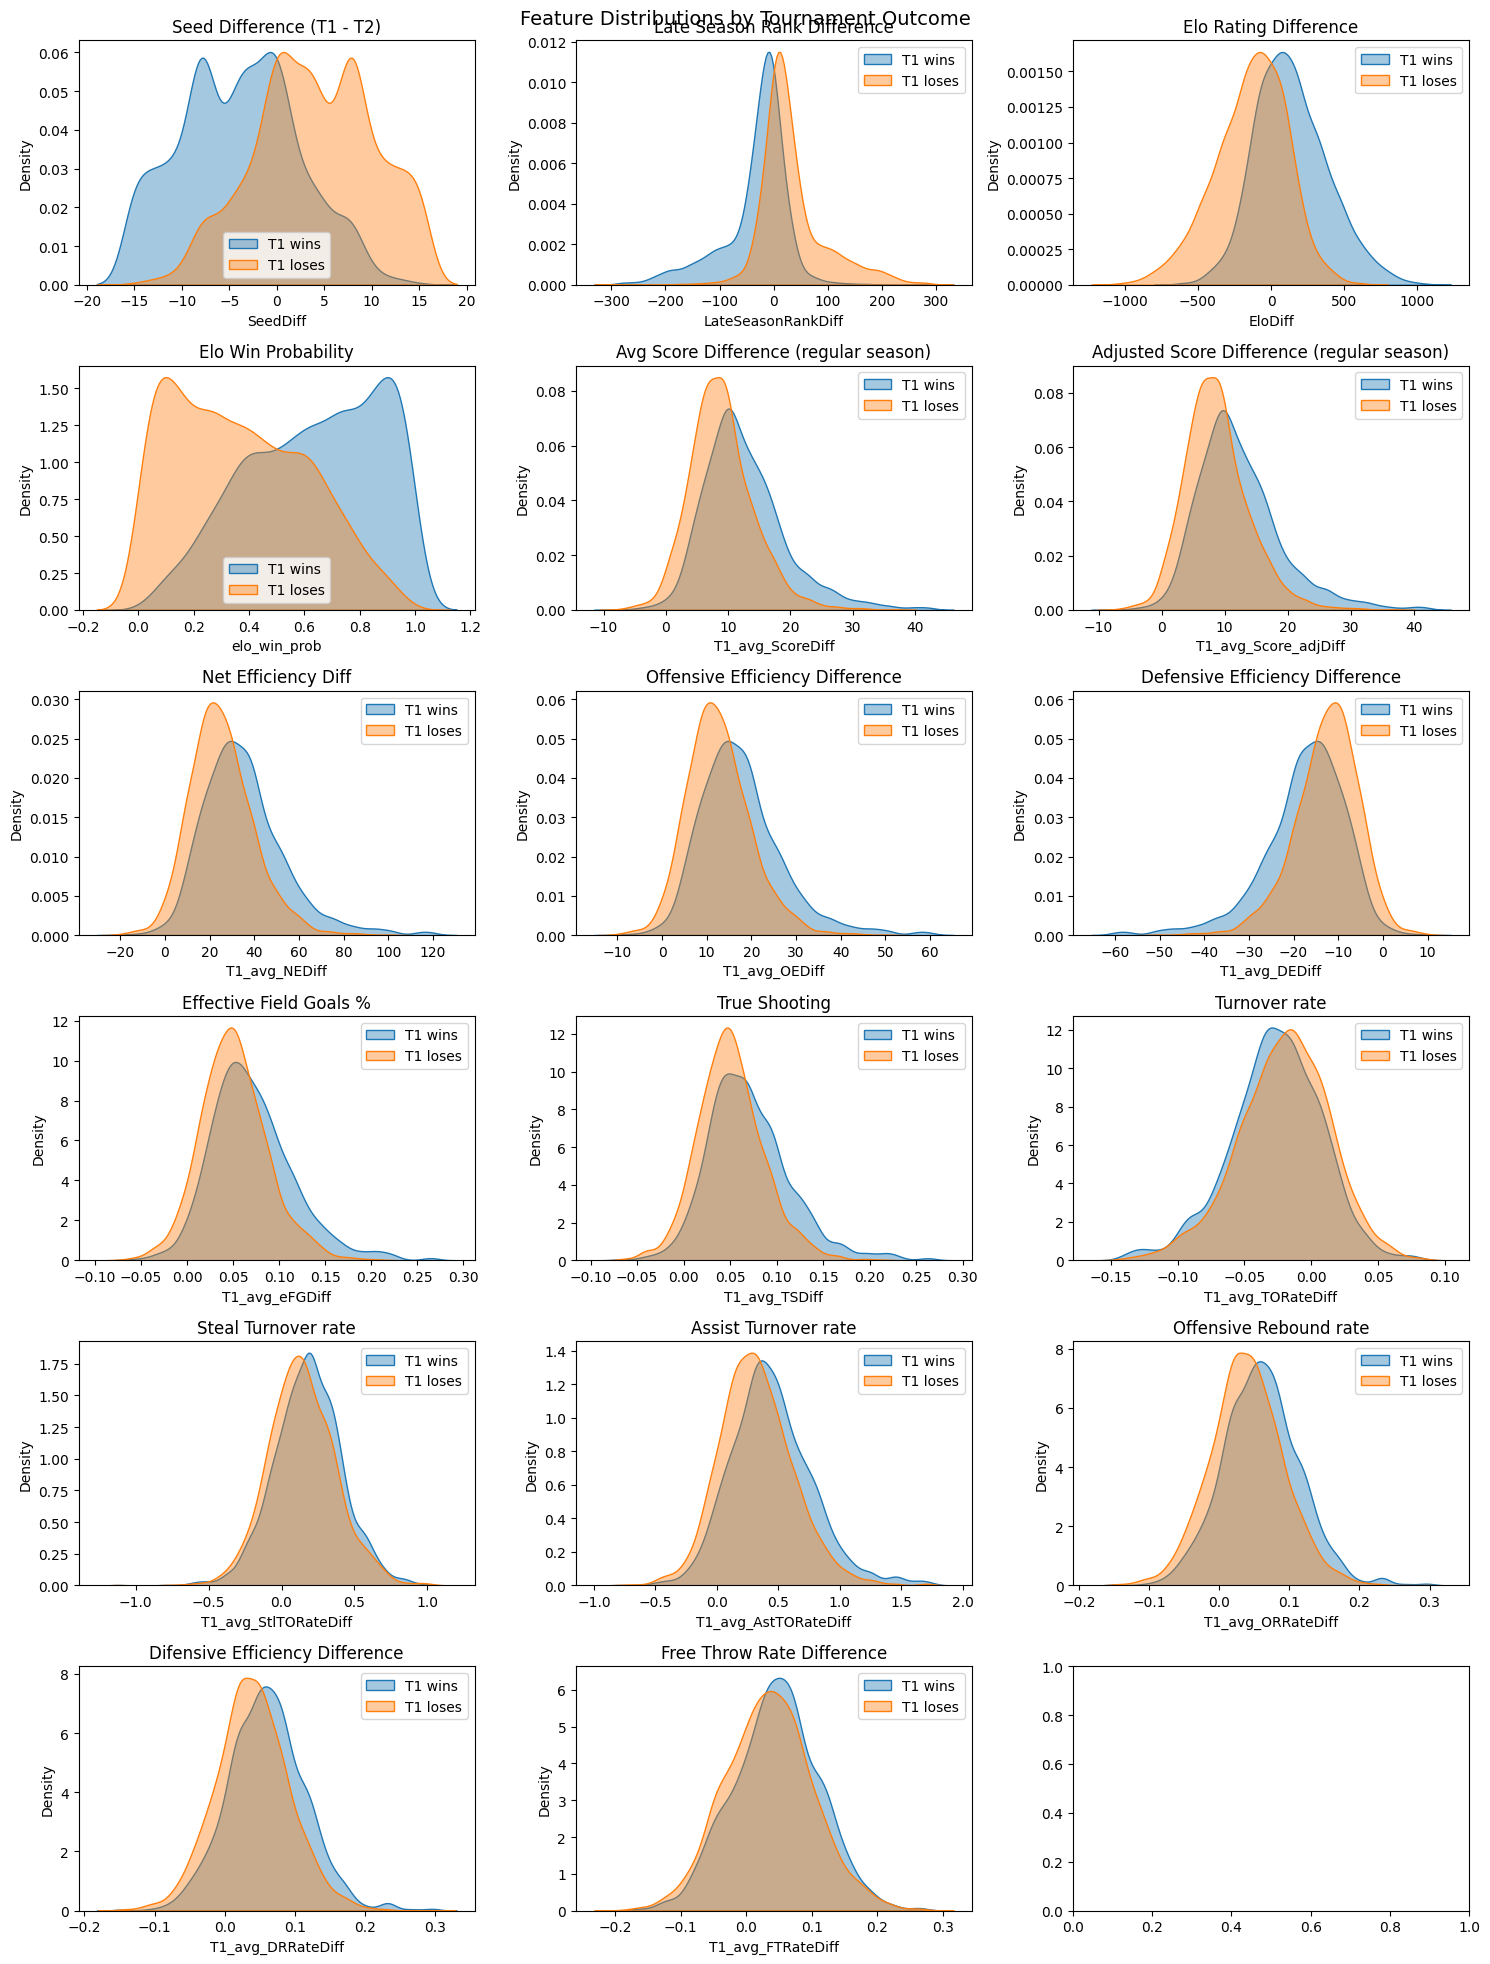

In [162]:
# Distribution of key engineered features, split by tournament outcome
features_to_plot = {
    'SeedDiff':          'Seed Difference (T1 - T2)',
    'LateSeasonRankDiff':'Late Season Rank Difference',
    'EloDiff':           'Elo Rating Difference',
    'elo_win_prob':      'Elo Win Probability',
    'T1_avg_ScoreDiff':  'Avg Score Difference (regular season)',
    'T1_avg_Score_adjDiff':  'Adjusted Score Difference (regular season)',
    'T1_avg_NEDiff':     'Net Efficiency Diff',
    'T1_avg_OEDiff':     'Offensive Efficiency Difference',
    'T1_avg_DEDiff':     'Defensive Efficiency Difference',
    'T1_avg_eFGDiff':    'Effective Field Goals %',
    'T1_avg_TSDiff':     'True Shooting',
    'T1_avg_TORateDiff': 'Turnover rate',
    'T1_avg_StlTORateDiff':      'Steal Turnover rate',
    'T1_avg_AstTORateDiff': 'Assist Turnover rate',
    'T1_avg_ORRateDiff':     'Offensive Rebound rate',
    'T1_avg_DRRateDiff':     'Difensive Efficiency Difference',
    'T1_avg_FTRateDiff':     'Free Throw Rate Difference',
}

wins   = tourney_results_with_features[tourney_results_with_features['Outcome'] == "win"]
losses = tourney_results_with_features[tourney_results_with_features['Outcome'] == "lose"]

fig, axes = plt.subplots(6, 3, figsize=(15, 20))
for ax, (col, title) in zip(axes.flat, features_to_plot.items()):
    seaborn.kdeplot(wins[col].dropna(),   label='T1 wins',  ax=ax, fill=True, alpha=0.4)
    seaborn.kdeplot(losses[col].dropna(), label='T1 loses', ax=ax, fill=True, alpha=0.4)
    ax.set_title(title)
    ax.legend()
plt.suptitle('Feature Distributions by Tournament Outcome', fontsize=14)
plt.tight_layout()
plt.show()

## Predicting the outcomes!
To predict the outcomes, we can either do it by classifying the match (win/lose) or by predicting the score difference, thus deriving the probability of the outcome depending on the magnitude of the difference. We will try both methods, using XGBOOST model.

As a cross-validation method, we will use one-season-out method: we keep one season out and train on all the others, keeping separate models for each cv-fold and optimize the hyperparameters on those out-of-fold seasons.  

Hyperparameter optimization is done with **optuna**, a smart library for hp optimization.

**NOTE FOR SHARIQ, YOU MIGHT INVESTIGATE THIS**
- try a different model (i heard simple logistic regression might work well, but for this you need to transform the features into values between 0 and 1 and standardize them with mean 0 and variance 1.)
- during conversion from score_diff to probability of winning in `fit_predict_score_to_prob()`, we clip the output probability to 0.01,0.99. investigate whether we should clip or not and to which values



### 1. Regression on ScoreDiff
To predict the probability of winning of a team against the other, we will first do regression on the score difference between the 2 teams.  

We will always consider the POV of the first team (T1).

In [164]:
# we map "win", "lose" to 1, 0
tourney_results_with_features["Outcome"] = tourney_results_with_features["Outcome"].map(lambda x: 0 if x in ["lose", 0] else 1)

In [165]:


# cross-validation with one-season-out

def one_season_out_cv_regressor(df, feature_cols, target_col, params, verbose=False):

    oof_preds   = np.zeros(len(df))
    fold_scores = []

    for season in SEASONS:
        train = df[df['Season'] != season]
        val   = df[df['Season'] == season]

        X_train = train[feature_cols].values
        y_train = train[target_col].values
        X_val   = val[feature_cols].values
        y_val   = val[target_col].values

        model = xgb.XGBRegressor(
            **params,
            eval_metric='rmse',
            random_state=42,
        )
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

        preds = model.predict(X_val)
        oof_preds[val.index] = preds

        fold_scores.append({
            'season': season,
            'mae':  mean_absolute_error(y_val, preds),
            'rmse': np.sqrt(mean_squared_error(y_val, preds)),
        })

        if verbose:
            s = fold_scores[-1]
            print(f"Season {season} — MAE: {s['mae']:.2f}  RMSE: {s['rmse']:.2f}")

    scores_df = pd.DataFrame(fold_scores)
    if verbose:
        print(f"\nMean MAE  : {scores_df['mae'].mean():.2f} ± {scores_df['mae'].std():.2f}")
        print(f"Mean RMSE : {scores_df['rmse'].mean():.2f} ± {scores_df['rmse'].std():.2f}")

    return scores_df, oof_preds

# fit ScoreDiff and probability conversion on OOF predictions

def fit_predict_score_to_prob(oof_score_diffs, actual_outcomes):
    """
    Fit a univariate spline.
    Using OOF predictions ensures no leakage.
    """
    max_score_difference = 25 # we clip the score difference predictions to 25 to avoid over-confidence
    dat = list(zip(oof_score_diffs, np.array(actual_outcomes)>0))
    dat = sorted(dat, key = lambda x: x[0])
    pred, label = list(zip(*dat))
    spline_model = UnivariateSpline(np.clip(pred, -max_score_difference, max_score_difference), label, k=5)
    oof_probs = np.clip(spline_model
                        (np.clip(oof_score_diffs, -max_score_difference, max_score_difference)
                         ), 
                         0.01, 0.99) # those values clip the output probability. should we clip or not? and to which values?

    return oof_probs


### Score Diff Regression — Feature Set Comparison

We now repeat the **ScoreDiff regression** for all four feature sets to see how prediction quality changes with fewer or more features.  we run the same pipeline across all four and compare.



In [167]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

TARGET_COL_REG   = 'ScoreDiff'
OPTUNA_TRIALS_FS = 30   # increase to 100 for more trustworthy results

feature_sets_reg = {
    'all_features':         (all_features,                  tourney_results_with_features),
    'only_diff':            (only_diff_features,            tourney_results_with_features),
    'minimal_raw_boxscore': (minimal_raw_boxscore_features, tourney_results_with_features),
    'minimal_raw':          (minimal_raw_features,          tourney_results_with_features),
    'aug_feat_rs':          (AUG_FEAT_RS,                   trwf_aug),
}

oof_score_diffs_map = {}
oof_probs_map       = {}
scores_map_reg      = {}
best_params_reg     = {}

for name, (feat_cols, df) in feature_sets_reg.items():
    print(f"\n{'='*55}")
    print(f"  Feature set : {name}  ({len(feat_cols)} features)")
    print(f"{'='*55}")

    # Coerce Outcome to int (may be 'win'/'lose' strings in some dataframes)
    actual_outcomes = df['Outcome'].map(
        lambda x: 1 if x == 'win' else (0 if x == 'lose' else int(x))).values

    def objective_fs(trial):
        params = {
            'n_estimators':     trial.suggest_int('n_estimators', 100, 600),
            'max_depth':        trial.suggest_int('max_depth', 2, 6),
            'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 5, 30),
            'gamma':            trial.suggest_float('gamma', 0.0, 2.0),
            'reg_alpha':        trial.suggest_float('reg_alpha', 0.0, 2.0),
            'reg_lambda':       trial.suggest_float('reg_lambda', 0.5, 5.0),
        }
        sc, _ = one_season_out_cv_regressor(df, feat_cols, TARGET_COL_REG, params)
        return sc['rmse'].mean() + 0.5 * sc['rmse'].std()

    study_fs = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=42)
    )
    study_fs.optimize(objective_fs, n_trials=OPTUNA_TRIALS_FS, show_progress_bar=True)
    bp = study_fs.best_params
    best_params_reg[name] = bp

    scores_df_fs, oof_sd = one_season_out_cv_regressor(df, feat_cols, TARGET_COL_REG, bp)
    oof_probs_fs = fit_predict_score_to_prob(oof_sd, actual_outcomes)

    oof_score_diffs_map[name] = oof_sd
    oof_probs_map[name]       = oof_probs_fs
    scores_map_reg[name]      = scores_df_fs

    print(f"  CV MAE  : {scores_df_fs['mae'].mean():.2f} ± {scores_df_fs['mae'].std():.2f}")
    print(f"  CV RMSE : {scores_df_fs['rmse'].mean():.2f} ± {scores_df_fs['rmse'].std():.2f}")
    print(f"  Log-loss: {log_loss(actual_outcomes, oof_probs_fs):.4f}")
    print(f"  Brier   : {brier_score_loss(actual_outcomes, oof_probs_fs):.4f}")



  Feature set : all_features  (157 features)


  0%|          | 0/30 [00:00<?, ?it/s]

  CV MAE  : 9.26 ± 1.02
  CV RMSE : 11.61 ± 1.23
  Log-loss: 0.5187
  Brier   : 0.1759

  Feature set : only_diff  (30 features)


  0%|          | 0/30 [00:00<?, ?it/s]

  CV MAE  : 9.25 ± 1.03
  CV RMSE : 11.60 ± 1.24
  Log-loss: 0.5190
  Brier   : 0.1765

  Feature set : minimal_raw_boxscore  (68 features)


...

  CV MAE  : 9.27 ± 0.96
  CV RMSE : 11.62 ± 1.18
  Log-loss: 0.5177
  Brier   : 0.1756

  Feature set : minimal_raw  (15 features)


  0%|          | 0/30 [00:00<?, ?it/s]

  CV MAE  : 9.21 ± 0.97
  CV RMSE : 11.53 ± 1.18
  Log-loss: 0.5157
  Brier   : 0.1750

  Feature set : aug_feat_rs  (163 features)


  0%|          | 0/30 [00:00<?, ?it/s]

  CV MAE  : 9.24 ± 0.99
  CV RMSE : 11.55 ± 1.20
  Log-loss: 0.5165
  Brier   : 0.1754


#### ScoreDiff Regression — Results Comparison

- **Left**: calibrated win-probability curves for each feature set against actual outcomes.  
Transforming the score difference into a probability is needed, and for this we had to calibrate it by fitting a polynomial function (spline).

- **Right**: bar chart of CV MAE, RMSE, Log-Loss, and Brier Score — lower is better in all cases.

In [168]:
# ── Build summary table ──
summary_reg = pd.DataFrame({
    name: {
        'MAE':      scores_map_reg[name]['mae'].mean(),
        'RMSE':     scores_map_reg[name]['rmse'].mean(),
        'Log-Loss': log_loss(actual_outcomes_all, oof_probs_map[name]),
        'Brier':    brier_score_loss(actual_outcomes_all, oof_probs_map[name]),
    }
    for name in feature_sets_reg
}).T.reset_index().rename(columns={'index': 'Feature Set'})

feature_labels = summary_reg['Feature Set'].tolist()
colors = seaborn.color_palette('Set2', len(feature_labels))

fig = plt.figure(figsize=(18, 12))
fig.suptitle("Score Diff Regression — Feature Set Comparison", fontsize=14, fontweight='bold', y=1.01)

# ── Row 1: Calibrated probability curve (full width) ──
ax_prob = fig.add_subplot(3, 1, 1)
for name, oof_sd in oof_score_diffs_map.items():
    tmp = pd.DataFrame({
        'ScoreDiff':      oof_sd.astype(int),
        'CalibratedPred': oof_probs_map[name],
        'Outcome':        actual_outcomes_all,
    })
    agg = tmp.groupby('ScoreDiff')[['Outcome','CalibratedPred']].mean().reset_index()
    seaborn.lineplot(x=agg['ScoreDiff'], y=agg['CalibratedPred'], ax=ax_prob, label=name)

agg_actual = tmp.groupby('ScoreDiff')['Outcome'].mean().reset_index()
seaborn.lineplot(x=agg_actual['ScoreDiff'], y=agg_actual['Outcome'],
                 ax=ax_prob, label='actual', linestyle='--', color='black', linewidth=2)
ax_prob.set_xlabel("Predicted Score Diff")
ax_prob.set_ylabel("Win Probability")
ax_prob.set_title("Calibrated Win Probability by Feature Set")
ax_prob.legend(fontsize=9)
ax_prob.grid(axis='y', linestyle=':', alpha=0.5)

# ── Row 2 & 3: One subplot per metric ──
metrics_reg = ['MAE', 'RMSE', 'Log-Loss', 'Brier']
axes_m = [fig.add_subplot(3, 4, 5 + i) for i in range(4)]

for ax_m, metric in zip(axes_m, metrics_reg):
    vals = summary_reg[metric].values
    bars = ax_m.bar(feature_labels, vals, color=colors, edgecolor='white', linewidth=0.8)
    # annotate each bar
    for bar, val in zip(bars, vals):
        ax_m.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                  f'{val:.4f}', ha='center', va='bottom', fontsize=8)
    ax_m.set_title(metric, fontsize=11, fontweight='bold')
    ax_m.set_ylabel(metric, fontsize=9)
    ax_m.set_xticks(range(len(feature_labels)))
    ax_m.set_xticklabels(feature_labels, rotation=25, ha='right', fontsize=8)
    ax_m.set_ylim(0, max(vals) * 1.18)
    ax_m.grid(axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

print("\n=== Summary Table ===")
print(summary_reg.to_string(index=False))

NameError: name 'actual_outcomes_all' is not defined

  all_features                MAE=10.77  RMSE=13.75  LL=0.3839  Brier=0.1277
  only_diff                   MAE=10.60  RMSE=13.61  LL=0.3818  Brier=0.1269
  minimal_raw_boxscore        MAE=10.83  RMSE=13.79  LL=0.3853  Brier=0.1276
  minimal_raw                 MAE=10.74  RMSE=13.75  LL=0.3727  Brier=0.1253
  aug_feat_rs                 MAE=10.51  RMSE=13.64  LL=0.3746  Brier=0.1219


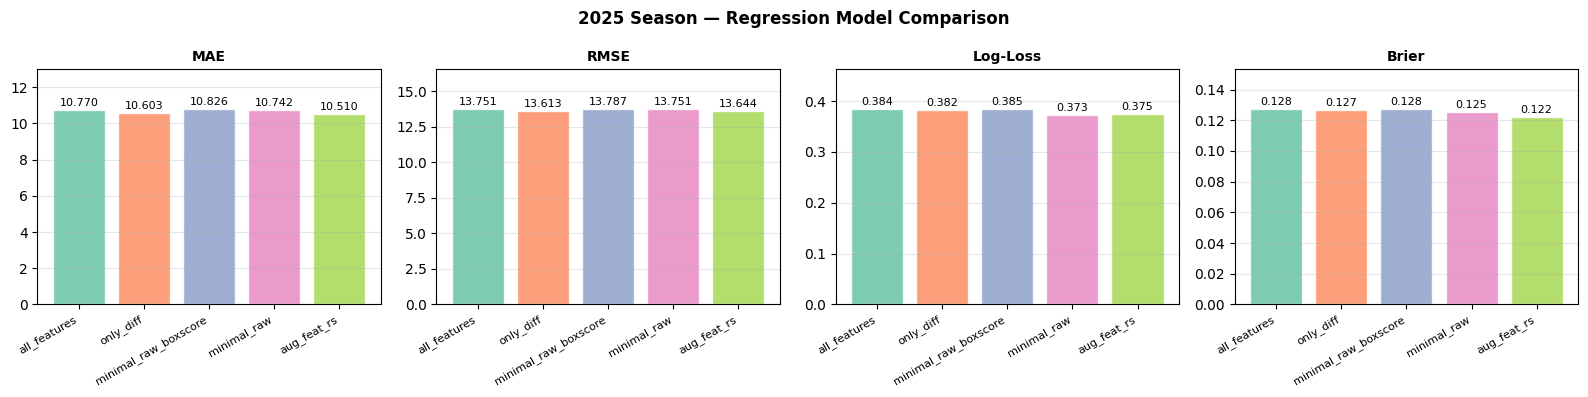


=== 2025 Regression Summary ===
         Feature Set       MAE      RMSE  Log-Loss    Brier
        all_features 10.769867 13.751147  0.383917 0.127662
           only_diff 10.603175 13.613064  0.381824 0.126870
minimal_raw_boxscore 10.826412 13.787150  0.385328 0.127640
         minimal_raw 10.741841 13.750956  0.372715 0.125267
         aug_feat_rs 10.510027 13.644418  0.374613 0.121918


In [169]:
# ── 2025 Season Evaluation — Regression (all feature sets) ──────────────────
EVAL_SEASON = 2025

results_2025_reg = []

for name, (feat_cols, df) in feature_sets_reg.items():
    # Train on all seasons except 2025
    train_df = df[df['Season'] != EVAL_SEASON].copy()
    test_df  = df[df['Season'] == EVAL_SEASON].copy()

    if test_df.empty:
        print(f"  {name}: no 2025 data found — skipping")
        continue

    y_train = train_df['ScoreDiff'].values
    y_test  = test_df['ScoreDiff'].values
    actual_outcomes_2025 = test_df['Outcome'].map(
        lambda x: 1 if x == 'win' else (0 if x == 'lose' else int(x))).values

    bp = best_params_reg[name]
    model = xgb.XGBRegressor(**bp, verbosity=0)
    model.fit(train_df[feat_cols].fillna(0), y_train)

    preds_sd = model.predict(test_df[feat_cols].fillna(0))
    probs    = fit_predict_score_to_prob(preds_sd, actual_outcomes_2025)

    mae   = mean_absolute_error(y_test, preds_sd)
    rmse  = mean_squared_error(y_test, preds_sd) ** 0.5
    ll    = log_loss(actual_outcomes_2025, probs)
    brier = brier_score_loss(actual_outcomes_2025, probs)

    results_2025_reg.append({'Feature Set': name, 'MAE': mae, 'RMSE': rmse,
                              'Log-Loss': ll, 'Brier': brier})
    print(f"  {name:<26}  MAE={mae:.2f}  RMSE={rmse:.2f}  LL={ll:.4f}  Brier={brier:.4f}")

reg25_df = pd.DataFrame(results_2025_reg)

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.patch.set_facecolor('white')
fig.suptitle(f'2025 Season — Regression Model Comparison', fontsize=12, fontweight='bold')
colors = plt.cm.Set2.colors

for ax, metric in zip(axes, ['MAE', 'RMSE', 'Log-Loss', 'Brier']):
    ax.set_facecolor('white')
    bars = ax.bar(reg25_df['Feature Set'], reg25_df[metric],
                  color=colors[:len(reg25_df)], edgecolor='white', alpha=0.85)
    for bar, val in zip(bars, reg25_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + reg25_df[metric].max()*0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    ax.set_title(metric, fontsize=10, fontweight='bold')
    ax.set_xticks(range(len(reg25_df)))
    ax.set_xticklabels(reg25_df['Feature Set'], rotation=30, ha='right', fontsize=8)
    ax.set_ylim(0, reg25_df[metric].max() * 1.2)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== 2025 Regression Summary ===")
print(reg25_df.to_string(index=False))


### 2. Classification on Outcome
To predict the probability of winning of a team against the other, we will now do classification, considering the Outcome column as a ground truth.  

In [57]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

TARGET_COL      = 'Outcome'
TARGET_SEASON   = 2025
SEASONS         = sorted(tourney_results_with_features['Season'].unique())
SEASONS.remove(TARGET_SEASON)
OPTUNA_TRIALS   = 20

def one_season_out_cv(df, feature_cols, target_col, params, verbose=False):
    oof_preds   = np.zeros(len(df))
    fold_scores = []
    for season in SEASONS:
        train_df = df[df['Season'] != season]
        val_df   = df[df['Season'] == season]
        X_tr  = train_df[feature_cols].values
        y_tr  = train_df[target_col].map(lambda x: 1 if x=='win' else (0 if x=='lose' else int(x))).values
        X_val = val_df[feature_cols].values
        y_val = val_df[target_col].map(lambda x: 1 if x=='win' else (0 if x=='lose' else int(x))).values

        model = xgb.XGBClassifier(**params, eval_metric='logloss', use_label_encoder=False, verbosity=0)
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        preds = model.predict_proba(X_val)[:, 1]
        oof_preds[df['Season'] == season] = preds

        from sklearn.metrics import log_loss, brier_score_loss
        fold_scores.append({
            'season':   season,
            'log_loss': log_loss(y_val, preds),
            'brier':    brier_score_loss(y_val, preds),
        })
    return oof_preds, pd.DataFrame(fold_scores)

def objective(trial, df, feature_cols, target_col):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 50, 300),
        'max_depth':        trial.suggest_int('max_depth', 2, 6),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
    }
    _, scores_df = one_season_out_cv(df, feature_cols, target_col, params)
    return scores_df['log_loss'].mean()

feature_sets = {
    'all_features':         (all_features,                  tourney_results_with_features),
    'only_diff':            (only_diff_features,            tourney_results_with_features),
    'minimal_raw_boxscore': (minimal_raw_boxscore_features, tourney_results_with_features),
    'minimal_raw':          (minimal_raw_features,          tourney_results_with_features),
    'aug_feat_rs':          (AUG_FEAT_RS,                   trwf_aug),
}

oof_results     = {}
best_params_map = {}
scores_map      = {}

for name, (feat_cols, df) in feature_sets.items():
    print(f"\n=== Feature set: {name} ({len(feat_cols)} features) ===")
    study = optuna.create_study(direction='minimize')
    study.optimize(lambda trial: objective(trial, df, feat_cols, TARGET_COL),
                   n_trials=OPTUNA_TRIALS, show_progress_bar=True)

    best_params = study.best_params
    best_params_map[name] = best_params

    oof_preds, scores_df = one_season_out_cv(df, feat_cols, TARGET_COL, best_params)
    oof_results[name] = oof_preds
    scores_map[name]  = scores_df

    print(f"  Log-loss:    {scores_df['log_loss'].mean():.4f}")
    print(f"  Brier score: {scores_df['brier'].mean():.4f}")

oof_preds = oof_results['minimal_raw']



=== Feature set: all_features (157 features) ===


  0%|          | 0/20 [00:00<?, ?it/s]

  Log-loss:    0.5135
  Brier score: 0.1726

=== Feature set: only_diff (30 features) ===


  0%|          | 0/20 [00:00<?, ?it/s]

  Log-loss:    0.5104
  Brier score: 0.1722

=== Feature set: minimal_raw_boxscore (68 features) ===


...

  Log-loss:    0.5110
  Brier score: 0.1726

=== Feature set: minimal_raw (15 features) ===


  0%|          | 0/20 [00:00<?, ?it/s]

  Log-loss:    0.5071
  Brier score: 0.1715

=== Feature set: aug_feat_rs (163 features) ===


  0%|          | 0/20 [00:00<?, ?it/s]

  Log-loss:    0.5083
  Brier score: 0.1716


### Classification Results — Feature Set Comparison

Below we compare the calibrated win-probability curves across all four feature sets to see how prediction quality shifts with more or fewer features.

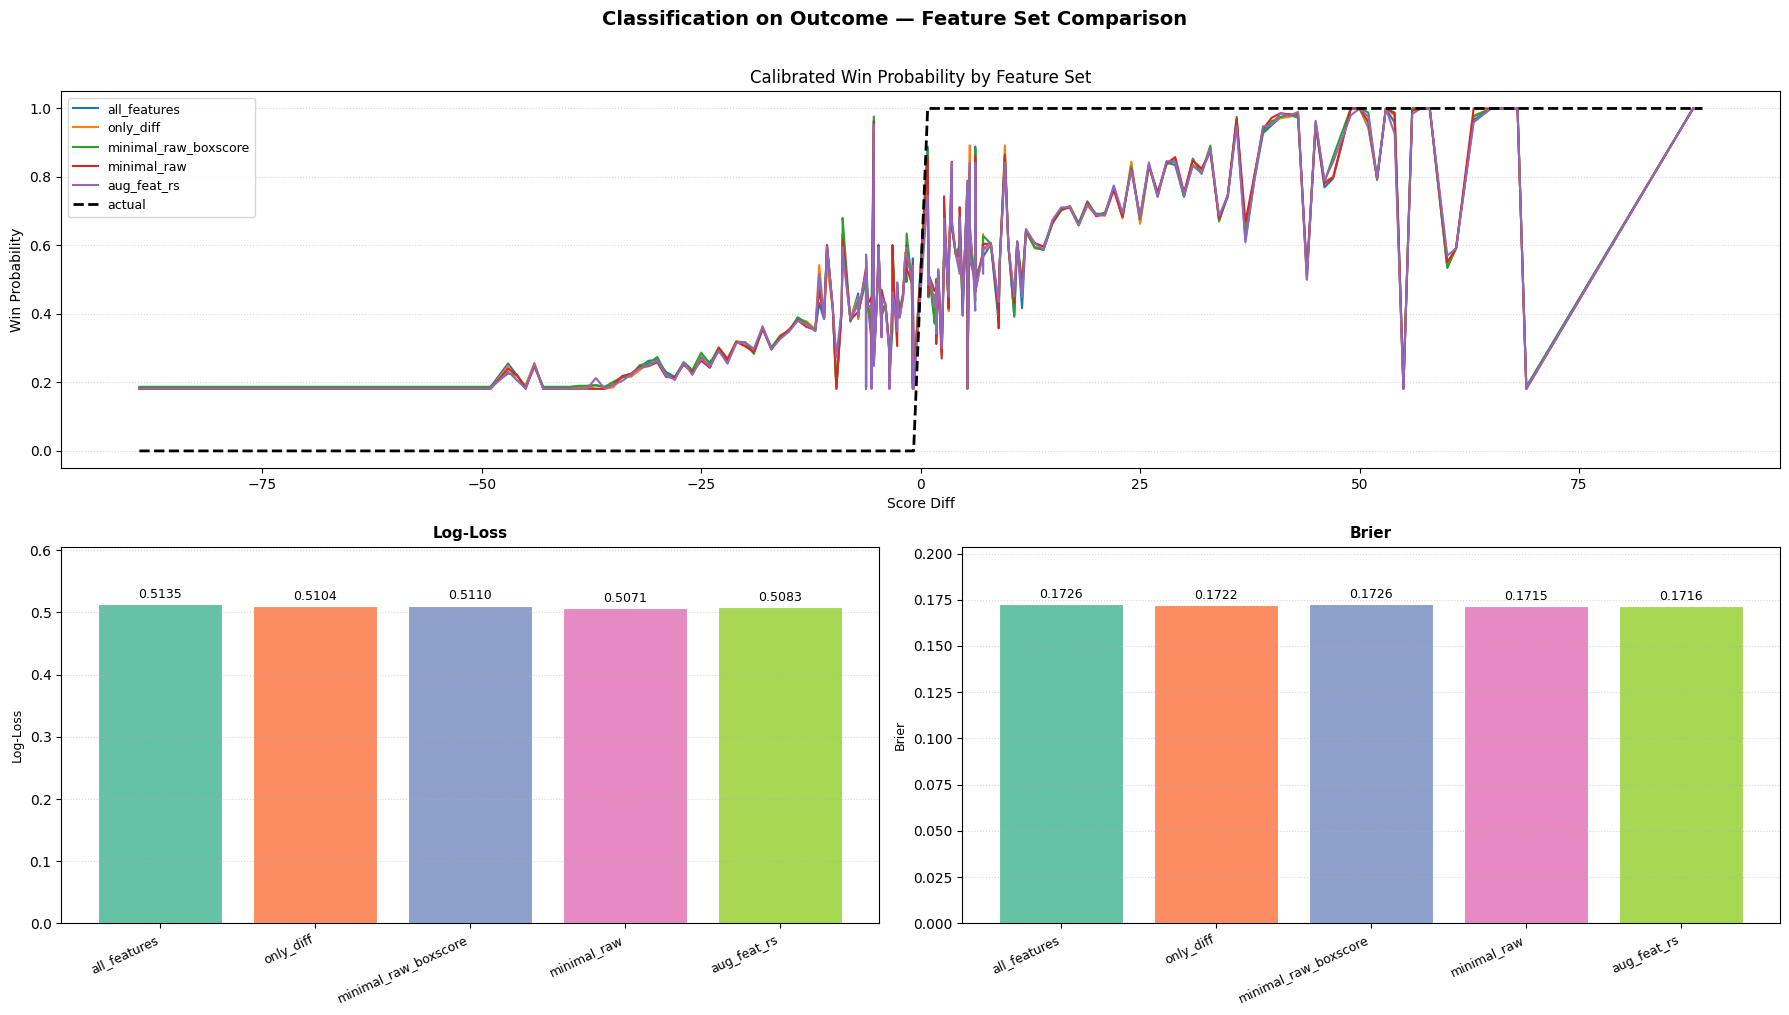


=== Summary Table ===
         Feature Set  Log-Loss    Brier
        all_features  0.513453 0.172626
           only_diff  0.510450 0.172191
minimal_raw_boxscore  0.510999 0.172574
         minimal_raw  0.507118 0.171518
         aug_feat_rs  0.508253 0.171644


In [61]:
from sklearn.isotonic import IsotonicRegression

# ── Calibrate and collect predictions ──
calibrated_results = {}
for name, oof_preds_fs in oof_results.items():
    tmp = df.copy()
    tmp['Pred'] = oof_preds_fs
    tmp['Outcome'] = tmp['Outcome'].map(lambda x: 1 if x=='win' else (0 if x=='lose' else int(x))).values
    cal = IsotonicRegression(out_of_bounds='clip')
    cal.fit(tmp['Pred'], tmp['Outcome'])
    tmp['CalibratedPred'] = cal.predict(tmp['Pred'])
    calibrated_results[name] = tmp

# ── Build summary table ──
summary = pd.DataFrame({
    name: {
        'Log-Loss': scores_map[name]['log_loss'].mean(),
        'Brier':    scores_map[name]['brier'].mean(),
    }
    for name in feature_sets
}).T.reset_index().rename(columns={'index': 'Feature Set'})

feature_labels_cls = summary['Feature Set'].tolist()
colors_cls = seaborn.color_palette('Set2', len(feature_labels_cls))

fig = plt.figure(figsize=(18, 10))
fig.suptitle("Classification on Outcome — Feature Set Comparison", fontsize=14, fontweight='bold', y=1.01)

# ── Row 1: Calibrated probability curve (full width) ──
ax_prob = fig.add_subplot(2, 1, 1)
for name, tmp in calibrated_results.items():
    agg = tmp.groupby('ScoreDiff')[['Outcome','CalibratedPred']].mean().reset_index()
    seaborn.lineplot(x=agg['ScoreDiff'], y=agg['CalibratedPred'], ax=ax_prob, label=name)

seaborn.lineplot(x=agg['ScoreDiff'], y=agg['Outcome'],
                 ax=ax_prob, label='actual', linestyle='--', color='black', linewidth=2)
ax_prob.set_xlabel("Score Diff")
ax_prob.set_ylabel("Win Probability")
ax_prob.set_title("Calibrated Win Probability by Feature Set")
ax_prob.legend(fontsize=9)
ax_prob.grid(axis='y', linestyle=':', alpha=0.5)

# ── Row 2: One subplot per metric ──
metrics_cls = ['Log-Loss', 'Brier']
axes_m = [fig.add_subplot(2, 2, 3 + i) for i in range(2)]

for ax_m, metric in zip(axes_m, metrics_cls):
    vals = summary[metric].values
    bars = ax_m.bar(feature_labels_cls, vals, color=colors_cls, edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, vals):
        ax_m.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                  f'{val:.4f}', ha='center', va='bottom', fontsize=9)
    ax_m.set_title(metric, fontsize=11, fontweight='bold')
    ax_m.set_ylabel(metric, fontsize=9)
    ax_m.set_xticks(range(len(feature_labels_cls)))
    ax_m.set_xticklabels(feature_labels_cls, rotation=25, ha='right', fontsize=9)
    ax_m.set_ylim(0, max(vals) * 1.18)
    ax_m.grid(axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

print("\n=== Summary Table ===")
print(summary.to_string(index=False))

  all_features                Acc=0.7985  LL=0.4327  Brier=0.1380
  only_diff                   Acc=0.8022  LL=0.4260  Brier=0.1376
  minimal_raw_boxscore        Acc=0.8022  LL=0.4183  Brier=0.1333
  minimal_raw                 Acc=0.7836  LL=0.4017  Brier=0.1299
  aug_feat_rs                 Acc=0.8022  LL=0.4068  Brier=0.1305


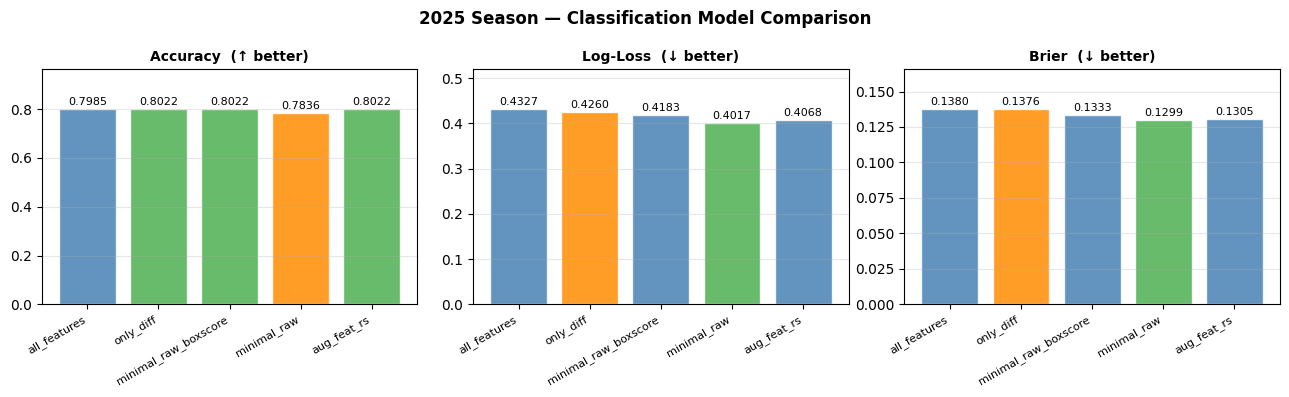

In [69]:
# ── 2025 Season Evaluation — Classification (all feature sets) ───────────────
results_2025_clf = []
EVAL_SEASON = 2025

for name, (feat_cols, df) in feature_sets.items():
    train_df = df[df['Season'] != EVAL_SEASON].copy()
    test_df  = df[df['Season'] == EVAL_SEASON].copy()

    if test_df.empty:
        print(f"  {name}: no 2025 data found — skipping")
        continue

    y_train = train_df['Outcome'].map(
        lambda x: 1 if x == 'win' else (0 if x == 'lose' else int(x))).values
    y_test  = test_df['Outcome'].map(
        lambda x: 1 if x == 'win' else (0 if x == 'lose' else int(x))).values

    bp = best_params_map[name]
    model = xgb.XGBClassifier(**bp, eval_metric='logloss', use_label_encoder=False, verbosity=0)
    model.fit(train_df[feat_cols].fillna(0), y_train)

    probs    = model.predict_proba(test_df[feat_cols].fillna(0))[:, 1]
    accuracy = ((probs >= 0.5) == y_test).mean()
    ll       = log_loss(y_test, probs)
    brier    = brier_score_loss(y_test, probs)

    results_2025_clf.append({'Feature Set': name, 'Accuracy': accuracy,
                              'Log-Loss': ll, 'Brier': brier})
    print(f"  {name:<26}  Acc={accuracy:.4f}  LL={ll:.4f}  Brier={brier:.4f}")

clf25_df = pd.DataFrame(results_2025_clf)

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.patch.set_facecolor('white')
fig.suptitle(f'2025 Season — Classification Model Comparison', fontsize=12, fontweight='bold')

for ax, (metric, lower_better) in zip(axes, [('Accuracy', False), ('Log-Loss', True), ('Brier', True)]):
    ax.set_facecolor('white')
    best_val = clf25_df[metric].min() if lower_better else clf25_df[metric].max()
    feat_colors = [colors[i % len(colors)] for i in range(len(clf25_df))]
   
    bar_colors = ['#4caf50' if v == best_val else feat_colors[i]
                  for i, v in enumerate(clf25_df[metric])]
    bars = ax.bar(clf25_df['Feature Set'], clf25_df[metric],
                  color=bar_colors, edgecolor='white', alpha=0.85)
    for bar, val in zip(bars, clf25_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + clf25_df[metric].max()*0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=8)
    ax.set_title(f'{metric}  ({"↓" if lower_better else "↑"} better)',
                 fontsize=10, fontweight='bold')
    ax.set_xticks(range(len(clf25_df)))
    ax.set_xticklabels(clf25_df['Feature Set'], rotation=30, ha='right', fontsize=8)
    ax.set_ylim(0, clf25_df[metric].max() * 1.2)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()



In [92]:
COMPARE_SEASON = 2024

# Pick best classification feature set by lowest CV Brier
best_clf_name = min(scores_map, key=lambda n: scores_map[n]['brier'].mean())
feat_cols, df = feature_sets[best_clf_name]
print(f"Best feature set: '{best_clf_name}'  "
      f"(CV Brier={scores_map[best_clf_name]['brier'].mean():.4f})")

# Train on all seasons except COMPARE_SEASON
train_df = df[df['Season'] != COMPARE_SEASON]
test_df  = df[df['Season'] == COMPARE_SEASON].copy()

y_train = train_df['Outcome'].map(lambda x: 1 if x=='win' else (0 if x=='lose' else int(x))).values
y_test  = test_df['Outcome'].map(lambda x: 1 if x=='win' else (0 if x=='lose' else int(x))).values

model = xgb.XGBClassifier(**best_params_map[best_clf_name],
                           eval_metric='logloss', use_label_encoder=False, verbosity=0)
model.fit(train_df[feat_cols].fillna(0), y_train)
probs = model.predict_proba(test_df[feat_cols].fillna(0))[:, 1]

test_df['PredProb']    = probs
test_df['PredOutcome'] = (probs >= 0.5).astype(int)
test_df['Actual']      = y_test
test_df['Correct']     = test_df['Actual'] == test_df['PredOutcome']

# Attach rounds
tourney_pg_r = tourney_pg.copy()
tourney_pg_r['Round'] = tourney_pg_r.groupby(['Season','Category'])['DayNum'].transform(
    lambda x: x.rank(method='dense').astype(int))
rnd_map = (tourney_pg_r[tourney_pg_r['Season'] == COMPARE_SEASON]
           [['T1TeamID','T2TeamID','Category','Round']]
           .assign(pair_key=lambda d:
               d[['T1TeamID','T2TeamID']].min(axis=1).astype(str) + '_' +
               d[['T1TeamID','T2TeamID']].max(axis=1).astype(str) + '_' +
               d['Category'].astype(str))
           [['pair_key','Round']].drop_duplicates())

test_df['pair_key'] = (
    test_df[['T1TeamID','T2TeamID']].min(axis=1).astype(int).astype(str) + '_' +
    test_df[['T1TeamID','T2TeamID']].max(axis=1).astype(int).astype(str) + '_' +
    test_df['Category'].astype(int).astype(str))
test_df = test_df.merge(rnd_map, on='pair_key', how='left').drop(columns='pair_key')

lookup  = pd.concat([M_teams_lookup, W_teams_lookup]).drop_duplicates('TeamID')
id2name = lookup.set_index('TeamID')['TeamName']

print(f"\nSeason {COMPARE_SEASON} — '{best_clf_name}' predictions vs actuals")
print("=" * 68)

for rnd in sorted(test_df['Round'].dropna().unique()):
    rdf = test_df[test_df['Round'] == rnd]
    print(f"\nRound {int(rnd)}  ({len(rdf)} games)  Accuracy={rdf['Correct'].mean():.3f}")
    print(f"  {'T1':<22} {'T2':<22} {'Act':>4}  {'P(T1)':>6}  {'':>3}")
    print(f"  {'-'*22} {'-'*22} {'---':>4}  {'------':>6}  {'---':>3}")
    for _, row in rdf.iterrows():
        t1n = id2name.get(int(row['T1TeamID']), str(int(row['T1TeamID'])))[:20]
        t2n = id2name.get(int(row['T2TeamID']), str(int(row['T2TeamID'])))[:20]
        print(f"  {t1n:<22} {t2n:<22} {int(row['Actual']):>4}  "
              f"{row['PredProb']:>6.3f}  {'✓' if row['Correct'] else '✗':>3}")

Best feature set: 'minimal_raw'  (CV Brier=0.1715)

Season 2024 — 'minimal_raw' predictions vs actuals

Round 1  (8 games)  Accuracy=0.250
  T1                     T2                      Act   P(T1)     
  ---------------------- ----------------------  ---  ------  ---
  Colorado St            Virginia                  1   0.570    ✓
  Wagner                 Howard                    1   0.388    ✗
  Presbyterian           Sacred Heart              1   0.308    ✗
  Vanderbilt             Columbia                  1   0.334    ✗
  Virginia               Colorado St               0   0.411    ✓
  Howard                 Wagner                    0   0.614    ✗
  Sacred Heart           Presbyterian              0   0.651    ✗
  Columbia               Vanderbilt                0   0.533    ✗

Round 2  (8 games)  Accuracy=0.625
  T1                     T2                      Act   P(T1)     
  ---------------------- ----------------------  ---  ------  ---
  Colorado               Boise St

### SHAP Value Analysis — Best Predictors

We train the best classification model (using `minimal_raw`) and use SHAP to explain which features drive predictions the most.

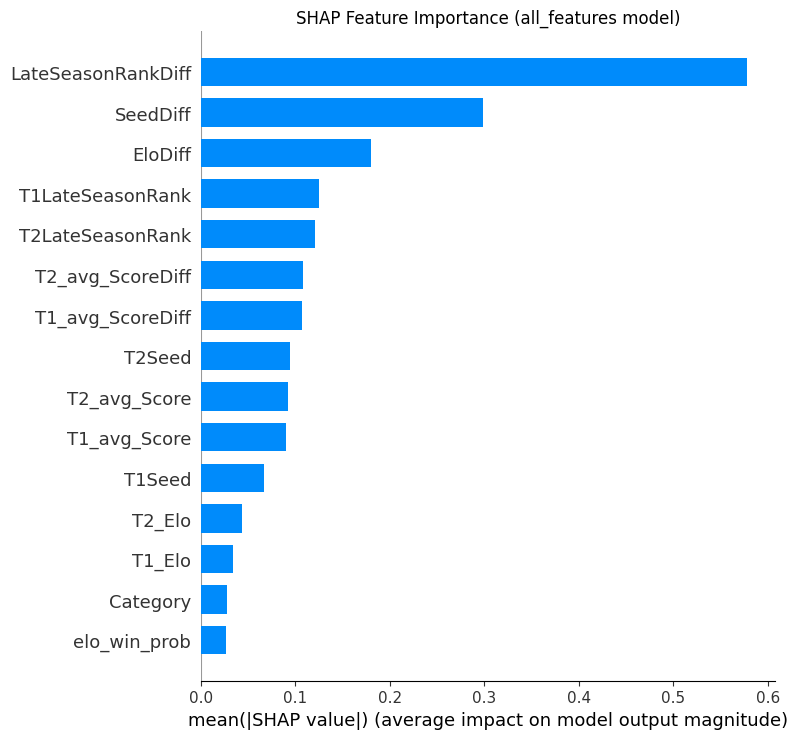

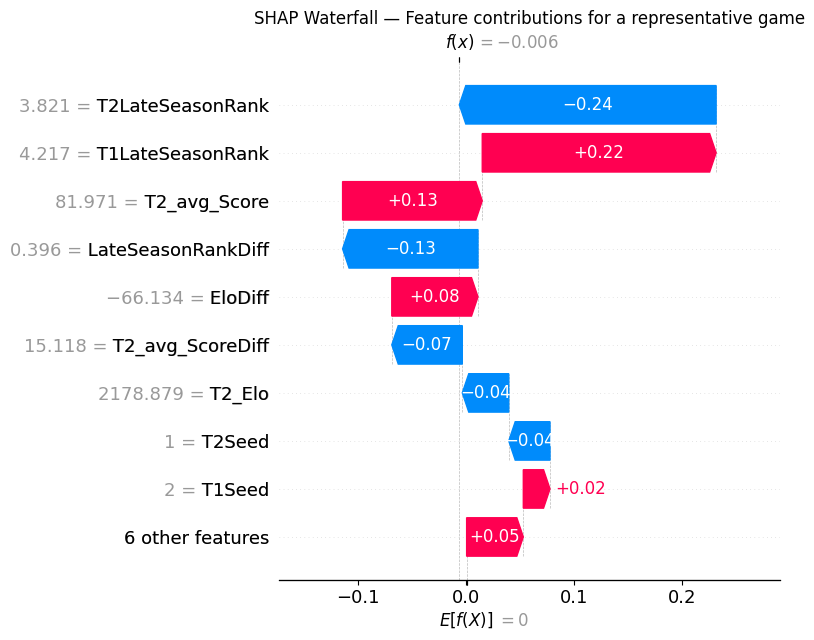

In [94]:
import shap

# Train a final XGBoost model on all data for SHAP explanation
shap_feature_set = minimal_raw_features
X_shap = tourney_results_with_features[shap_feature_set].values
y_shap = tourney_results_with_features[TARGET_COL].values

final_model = xgb.XGBClassifier(
    **best_params_map['minimal_raw'],
    eval_metric='logloss',
    use_label_encoder=False,
    verbosity=0
)
final_model.fit(X_shap, y_shap)

explainer    = shap.TreeExplainer(final_model)
shap_values  = explainer.shap_values(X_shap)

# Summary plot — feature importance ranked by mean |SHAP|
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_shap, feature_names=shap_feature_set, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (all_features model)")
plt.tight_layout()
plt.show()

# waterfall plot — shows direction and magnitude of each feature's impact

median_idx = np.argmin(np.abs(explainer.shap_values(X_shap).sum(axis=1) 
                               - np.median(explainer.shap_values(X_shap).sum(axis=1))))

exp = shap.Explanation(
    values      = shap_values[median_idx],
    base_values = float(explainer.expected_value),
    data        = X_shap[median_idx],
    feature_names = shap_feature_set
)

plt.style.use('default')
shap.plots.waterfall(exp, show=False)
plt.title("SHAP Waterfall — Feature contributions for a representative game")
plt.tight_layout()
plt.show()

#### SHAP Dependence Plots — Top 4 Features

For the top 4 most impactful features, we plot how the feature value maps to SHAP impact (coloured by the most interacting feature).

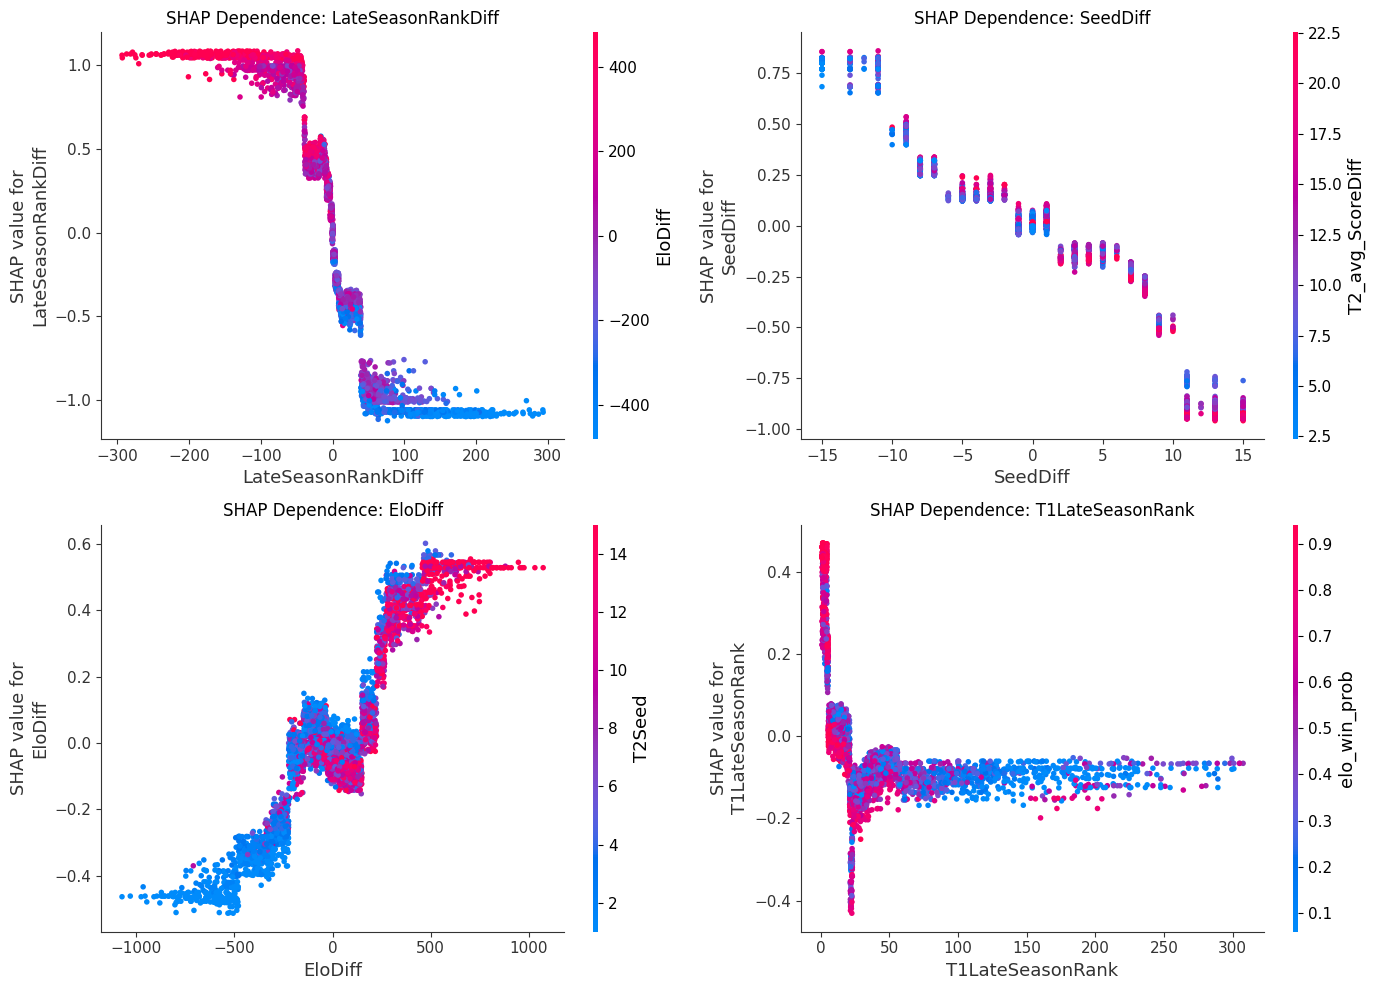

In [71]:
# Identify top-4 features by mean |SHAP|
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top4_idx      = np.argsort(mean_abs_shap)[::-1][:4]
top4_names    = [shap_feature_set[i] for i in top4_idx]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, feat_name in zip(axes.flatten(), top4_names):
    feat_idx = shap_feature_set.index(feat_name)
    shap.dependence_plot(
        feat_idx,
        shap_values,
        X_shap,
        feature_names=shap_feature_set,
        ax=ax,
        show=False
    )
    ax.set_title(f"SHAP Dependence: {feat_name}")

plt.tight_layout()
plt.show()

---
## 📅 Temporal Stability Analysis

Uses the already-trained `final_model` and `explainer` — no retraining.

| Cell | What it shows |
|---|---|
| **Compute** | Per-season Brier score + SHAP importances |
| **Brier trend** | Brier score per season — flat = stable, drift = concept drift |
| **Feature stability** | SHAP importances per season — heatmap + rank-variance bar chart |

In [79]:
import numpy as np
import pandas as pd
import shap
from sklearn.metrics import brier_score_loss

STABILITY_FEAT = shap_feature_set
df_all = tourney_results_with_features.copy()
all_seasons = sorted(df_all['Season'].unique())

brier_rows, season_importances = [], {}

for season in all_seasons:
    sdf = df_all[df_all['Season'] == season]
    if len(sdf) < 5:
        continue
    X_s = sdf[STABILITY_FEAT].fillna(0).values
    y_s = sdf['Outcome'].values
    preds = final_model.predict_proba(X_s)[:, 1]
    brier_rows.append({'Season': season, 'Brier': brier_score_loss(y_s, preds)})
    sv = explainer.shap_values(X_s)
    season_importances[season] = np.abs(sv).mean(axis=0)

brier_df = pd.DataFrame(brier_rows)
print(brier_df.to_string(index=False))


 Season    Brier
   2003 0.178403
   2004 0.166423
   2005 0.168739
   2006 0.189566
   2007 0.127926
   2008 0.147231
   2009 0.150707
   2010 0.156398
   2011 0.169868
   2012 0.147665
   2013 0.172250
   2014 0.164593
   2015 0.137952
   2016 0.173170
   2017 0.152413
   2018 0.163411
   2019 0.130155
   2021 0.175440
   2022 0.168036
   2023 0.173282
   2024 0.154036
   2025 0.119002


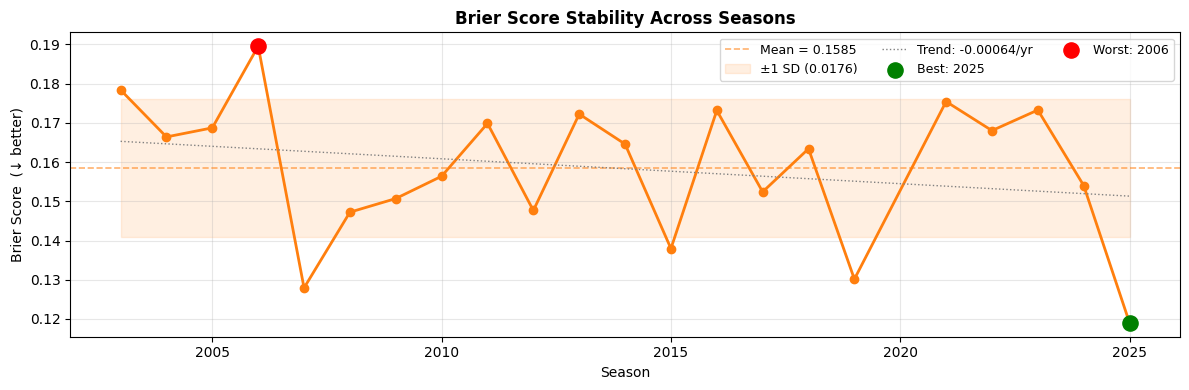

In [80]:
import matplotlib.pyplot as plt

seasons_x = brier_df['Season'].values
brier_v   = brier_df['Brier'].values
mean_b, std_b = brier_v.mean(), brier_v.std()
trend = np.polyfit(seasons_x, brier_v, 1)

fig, ax = plt.subplots(figsize=(12, 4))
fig.patch.set_facecolor('white'); ax.set_facecolor('white')
ax.plot(seasons_x, brier_v, 'o-', color='#ff7f0e', lw=2, ms=6)
ax.axhline(mean_b, color='#ff7f0e', ls='--', lw=1.2, alpha=0.6, label=f'Mean = {mean_b:.4f}')
ax.fill_between(seasons_x, mean_b - std_b, mean_b + std_b,
                color='#ff7f0e', alpha=0.12, label=f'±1 SD ({std_b:.4f})')
ax.plot(seasons_x, np.poly1d(trend)(seasons_x), color='grey', lw=1, ls=':',
        label=f'Trend: {trend[0]:+.5f}/yr')
ax.scatter(seasons_x[brier_v.argmin()], brier_v.min(), s=120, color='green',
           zorder=5, label=f'Best: {seasons_x[brier_v.argmin()]}')
ax.scatter(seasons_x[brier_v.argmax()], brier_v.max(), s=120, color='red',
           zorder=5, label=f'Worst: {seasons_x[brier_v.argmax()]}')
ax.set_xlabel('Season'); ax.set_ylabel('Brier Score  (↓ better)')
ax.set_title('Brier Score Stability Across Seasons', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, ncol=3); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


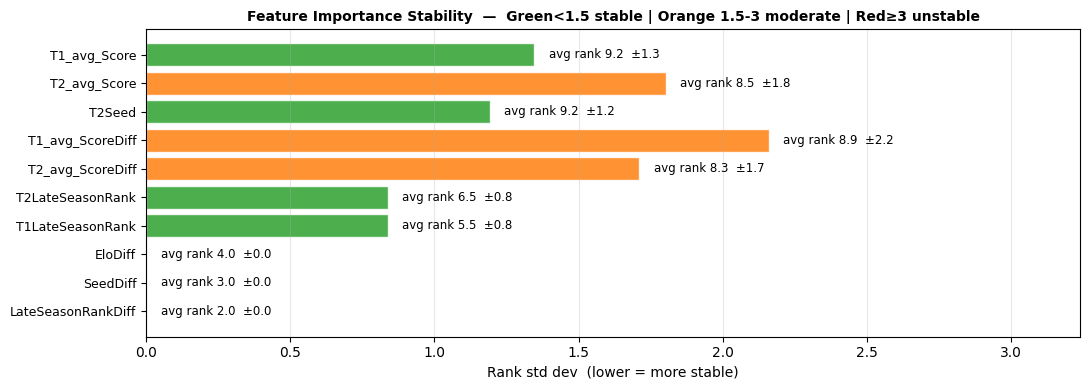

In [81]:
imp_seasons = [s for s in all_seasons if s in season_importances]
imp_matrix  = np.array([season_importances[s] for s in imp_seasons])   # (S, F)

top_n     = min(10, len(STABILITY_FEAT))
top_idx   = np.argsort(imp_matrix.mean(axis=0))[::-1][:top_n]
top_names = [STABILITY_FEAT[i] for i in top_idx]
imp_top   = imp_matrix[:, top_idx]                                       # (S, top_n)

rank_matrix = np.array([
    len(top_names) + 1 - np.argsort(np.argsort(imp_top[s_i]))
    for s_i in range(len(imp_seasons))
])
rank_std  = rank_matrix.std(axis=0)
rank_mean = rank_matrix.mean(axis=0)
colors_bar = ['#2ca02c' if s < 1.5 else '#ff7f0e' if s < 3.0 else '#d62728' for s in rank_std]

fig, ax = plt.subplots(figsize=(11, 4))
fig.patch.set_facecolor('white'); ax.set_facecolor('white')
bars = ax.barh(range(top_n), rank_std, color=colors_bar, alpha=0.85, edgecolor='white')
ax.set_yticks(range(top_n)); ax.set_yticklabels(top_names, fontsize=9)
ax.set_xlabel('Rank std dev  (lower = more stable)')
ax.set_title('Feature Importance Stability  —  Green<1.5 stable | Orange 1.5-3 moderate | Red≥3 unstable',
             fontsize=10, fontweight='bold')
for bar, std_v, mean_v in zip(bars, rank_std, rank_mean):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'avg rank {mean_v:.1f}  ±{std_v:.1f}', va='center', fontsize=8.5)
ax.set_xlim(0, max(rank_std.max() * 1.5, 1)); ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()


---
## 🏀 Interactive Team Dashboard

Explore any team's **strengths & weaknesses** and **Elo rating evolution** across seasons.

Use the dropdowns to select:
- **Gender** → Men or Women
- **Season** → any season available in the data
- **Team** → team name auto-loaded from `MTeams.csv` / `WTeams.csv`

Two views are available:
1. **Strength & Weakness** — radar chart of key metrics percentile-ranked vs the rest of the league that season, plus an offensive/defensive breakdown bar chart
2. **Elo History** — game-by-game Elo evolution within the selected season, plus season-end Elo trajectory across all seasons


In [ ]:
# ── Team name lookups ──────────────────────────────────────────────────────
import os

def _load_teams(path, fallback_path=None):
    for p in [path, fallback_path]:
        if p and os.path.exists(p):
            return pd.read_csv(p)[['TeamID','TeamName']]
    return pd.DataFrame(columns=['TeamID','TeamName'])

M_teams_lookup = _load_teams(
    f"{data_dir}/MTeams.csv",
    f"{data_dir}/mteams.csv"
)
W_teams_lookup = _load_teams(
    f"{data_dir}/WTeams.csv",
    f"{data_dir}/wteams.csv"
)


In [ ]:
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Column names produced by build_per_game_features ─────────────────────
# Format: T1OE, T1DE, T1eFG … (no underscore between prefix and stat name)
RADAR_STATS = {
    'OE':     ('Offensive Efficiency', True),
    'DE':     ('Defensive Efficiency', False),
    'eFG':    ('Eff. FG%',             True),
    'ORRate': ('Off. Reb Rate',        True),
    'TORate': ('Turnover Rate',        False),
    'FTRate': ('FT Rate',              True),
    'Score':  ('Points Scored',        True),
    'Ast':    ('Assists',              True),
    'Blk':    ('Blocks',               True),
    'Stl':    ('Steals',               True),
}
RADAR_COLS    = [f'T1{s}' for s in RADAR_STATS]
RADAR_LABELS  = [v[0] for v in RADAR_STATS.values()]
HIGHER_BETTER = [v[1] for v in RADAR_STATS.values()]

OFF_STATS = {
    'T1OE':     ('Off. Efficiency', True),
    'T1eFG':    ('Eff. FG%',        True),
    'T1ORRate': ('Off. Reb Rate',   True),
    'T1FTRate': ('FT Rate',         True),
    'T1TORate': ('Turnover Rate',   False),
}
DEF_STATS = {
    'T1DE':     ('Def. Efficiency',   False),
    'T2ORRate': ('Opp. Off Reb Rate', False),
    'T2TORate': ('Force Turnovers',   True),
    'T2Score':  ('Opp. Score',        False),
    'T1Blk':    ('Blocks',            True),
}

# ── Data fetch helpers ────────────────────────────────────────────────────
def get_team_stats(team_id, season, cat):
    src = regular_results_per_game_stats_with_elo
    return src[(src['Category']==cat) & (src['Season']==season) & (src['T1TeamID']==team_id)].copy()

def get_league_stats(season, cat):
    src = regular_results_per_game_stats_with_elo
    return src[(src['Category']==cat) & (src['Season']==season)].copy()

def pct_rank(val, series, higher_better):
    return (series < val).mean() if higher_better else (series > val).mean()

def z_score(val, series, higher_better):
    mu, sigma = series.mean(), series.std()
    if sigma == 0: return 0.0
    return ((val - mu) / sigma) * (1 if higher_better else -1)

def draw_radar(ax, values, labels, title, color='#4C72B0'):
    N      = len(values)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    v      = values + [values[0]]
    a      = angles + [angles[0]]
    ax.set_theta_offset(np.pi/2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles), labels, fontsize=8)
    ax.plot(a, v, color=color, linewidth=2)
    ax.fill(a, v, color=color, alpha=0.25)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['25th','50th','75th','100th'], fontsize=6, color='grey')
    ax.set_title(title, fontsize=11, fontweight='bold', pad=14)

print("Dashboard helpers loaded.")

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def plot_strength_weakness(team_name, team_id, season, cat, gender):
    team_df   = get_team_stats(team_id, season, cat)
    league_df = get_league_stats(season, cat)
    if team_df.empty:
        print(f"No data for {team_name} in {season}.")
        return

    fig = plt.figure(figsize=(18, 8))
    fig.suptitle(f"{team_name}  |  {gender}  |  Season {season}  — Strength & Weakness",
                 fontsize=14, fontweight='bold')
    gs = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[1.1, 1])

    ax_radar = fig.add_subplot(gs[0], polar=True)
    pcts, labels = [], []
    for col, label, hb in zip(RADAR_COLS, RADAR_LABELS, HIGHER_BETTER):
        if col in team_df.columns:
            tv = team_df[col].mean()
            ls = league_df[col].dropna()
            if len(ls) > 0 and not np.isnan(tv):
                pcts.append(pct_rank(tv, ls, hb))
                labels.append(label)
    if pcts:
        draw_radar(ax_radar, pcts, labels, f"Percentile vs League ({season})")
    else:
        ax_radar.text(0, 0, 'No radar data', ha='center', va='center')

    ax_bar = fig.add_subplot(gs[1])
    b_labels, b_vals, b_colors = [], [], []
    for col, (label, hb) in {**OFF_STATS, **DEF_STATS}.items():
        if col in team_df.columns:
            tv = team_df[col].mean()
            ls = league_df[col].dropna()
            if len(ls) > 1 and not np.isnan(tv):
                z = z_score(tv, ls, hb)
                b_labels.append(label)
                b_vals.append(z)
                b_colors.append('#4C72B0' if z >= 0 else '#C44E52')

    if b_vals:
        y = np.arange(len(b_labels))
        ax_bar.barh(y, b_vals, color=b_colors, edgecolor='white', height=0.6)
        ax_bar.set_yticks(y)
        ax_bar.set_yticklabels(b_labels, fontsize=9)
        ax_bar.axvline(0, color='black', lw=0.8, linestyle='--')
        ax_bar.set_xlabel("Z-score vs League Avg  (positive = better)", fontsize=9)
        ax_bar.set_title("Offensive & Defensive Z-Scores", fontsize=11, fontweight='bold')
        ax_bar.grid(axis='x', linestyle=':', alpha=0.5)
        for i, v in enumerate(b_vals):
            ax_bar.text(v + (0.03 if v >= 0 else -0.03), i, f'{v:+.2f}',
                        va='center', ha='left' if v >= 0 else 'right', fontsize=8)
    else:
        ax_bar.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax_bar.transAxes)

    plt.tight_layout()
    plt.show()

print("plot_strength_weakness() ready.")

In [ ]:
def plot_elo_history(team_name, team_id, season, cat, gender):
    src = regular_results_per_game_stats_with_elo

    t1 = src[(src['Category']==cat)&(src['Season']==season)&(src['T1TeamID']==team_id)]             [['DayNum','T1_Elo_Before','Outcome']].copy()
    t1.rename(columns={'T1_Elo_Before':'Elo','Outcome':'outcome'}, inplace=True)
    t1['won'] = t1['outcome'].isin(['win', 1])

    t2 = src[(src['Category']==cat)&(src['Season']==season)&(src['T2TeamID']==team_id)]             [['DayNum','T2_Elo_Before','Outcome']].copy()
    t2.rename(columns={'T2_Elo_Before':'Elo','Outcome':'outcome'}, inplace=True)
    t2['won'] = t2['outcome'].isin(['lose', 0])

    games = pd.concat([t1, t2]).sort_values('DayNum').reset_index(drop=True)
    games['Game'] = range(1, len(games)+1)

    elo_hist = pd.DataFrame([
        {'Season': s, 'Elo': e}
        for (s, tid), e in season_end_elo.items()
        if tid == team_id
        and src[(src['T1TeamID']==team_id)&(src['Season']==s)&(src['Category']==cat)].shape[0] > 0
    ]).sort_values('Season') if season_end_elo else pd.DataFrame()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle(f"{team_name}  |  {gender}  |  Elo History", fontsize=14, fontweight='bold')

    if not games.empty:
        ax1.plot(games['Game'], games['Elo'], color='#4C72B0', lw=2)
        ax1.scatter(games[games['won']]['Game'],  games[games['won']]['Elo'],
                    color='#55A868', s=60, marker='o', zorder=3, label='Win')
        ax1.scatter(games[~games['won']]['Game'], games[~games['won']]['Elo'],
                    color='#C44E52', s=60, marker='x', zorder=3, label='Loss')
        ax1.axhline(1500, color='grey', lw=0.8, linestyle='--', label='Baseline (1500)')
        ax1.set_xlabel("Game Number"); ax1.set_ylabel("Elo (pre-game)")
        ax1.set_title(f"Within-Season Elo — {season}", fontweight='bold')
        ax1.legend(fontsize=9); ax1.grid(axis='y', linestyle=':', alpha=0.5)
    else:
        ax1.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax1.transAxes)

    if not elo_hist.empty:
        ax2.plot(elo_hist['Season'], elo_hist['Elo'], color='#DD8452', lw=2, marker='o', markersize=6)
        sel = elo_hist[elo_hist['Season']==season]
        if not sel.empty:
            ax2.scatter(sel['Season'], sel['Elo'], color='gold', s=120,
                        edgecolors='black', lw=1.5, zorder=3, label=f'Selected ({season})')
        ax2.axhline(1500, color='grey', lw=0.8, linestyle='--', label='Baseline (1500)')
        ax2.fill_between(elo_hist['Season'], elo_hist['Elo'], 1500,
                         where=elo_hist['Elo']>=1500, alpha=0.15, color='#55A868')
        ax2.fill_between(elo_hist['Season'], elo_hist['Elo'], 1500,
                         where=elo_hist['Elo']<1500,  alpha=0.15, color='#C44E52')
        ax2.set_xlabel("Season"); ax2.set_ylabel("Season-End Elo")
        ax2.set_title("Season-End Elo Across All Seasons", fontweight='bold')
        ax2.legend(fontsize=9); ax2.grid(axis='y', linestyle=':', alpha=0.5)
    else:
        ax2.text(0.5, 0.5, 'No cross-season data', ha='center', va='center', transform=ax2.transAxes)

    plt.tight_layout()
    plt.show()

print("plot_elo_history() ready.")

In [ ]:
# ── Run this cell once. Use the button to render. ────────────────────────
import ipywidgets as widgets
from IPython.display import display as ipy_display, clear_output

_src = regular_results_per_game_stats_with_elo

def _seasons(cat):
    return sorted(_src[_src['Category']==cat]['Season'].unique().tolist(), reverse=True)

def _teams(cat, season):
    lk  = M_teams_lookup if cat == 0 else W_teams_lookup
    ids = pd.concat([
        _src[(_src['Category']==cat)&(_src['Season']==season)]['T1TeamID'],
        _src[(_src['Category']==cat)&(_src['Season']==season)]['T2TeamID']
    ]).unique()
    return sorted(lk[lk['TeamID'].isin(ids)]['TeamName'].tolist())

# ── Widgets ───────────────────────────────────────────────────────────────
gender_w = widgets.ToggleButtons(options=['Men','Women'], value='Men',
                                  description='Gender:', style={'button_width':'80px'})
season_w = widgets.Dropdown(options=_seasons(0), description='Season:',
                             layout=widgets.Layout(width='150px'))
team_w   = widgets.Dropdown(options=_teams(0, _seasons(0)[0]), description='Team:',
                             layout=widgets.Layout(width='270px'))
view_w   = widgets.ToggleButtons(options=['Strength & Weakness','Elo History'],
                                  description='View:', style={'button_width':'160px'})
btn      = widgets.Button(description='Show Dashboard', button_style='primary',
                           icon='bar-chart', layout=widgets.Layout(width='170px'))

controls = widgets.VBox([
    widgets.HBox([gender_w, season_w, team_w]),
    widgets.HBox([view_w, btn]),
])

# ── Cascade: only updates dropdown options, never renders ─────────────────
def _on_gender(change):
    if change['name'] != 'value': return
    cat = 0 if change['new'] == 'Men' else 1
    season_w.unobserve(_on_season, names='value')
    season_w.options = _seasons(cat)
    season_w.value   = season_w.options[0]
    team_w.options   = _teams(cat, season_w.value)
    team_w.value     = team_w.options[0] if team_w.options else None
    season_w.observe(_on_season, names='value')

def _on_season(change):
    if change['name'] != 'value': return
    cat = 0 if gender_w.value == 'Men' else 1
    team_w.options = _teams(cat, change['new'])
    team_w.value   = team_w.options[0] if team_w.options else None

gender_w.observe(_on_gender, names='value')
season_w.observe(_on_season, names='value')

# ── Button: clears ALL cell output, redraws controls, then plots ──────────
# plt.show() fires in normal cell-output context — no widget callback hooks
def on_click(_):
    cat    = 0 if gender_w.value == 'Men' else 1
    lookup = M_teams_lookup if cat == 0 else W_teams_lookup
    match  = lookup[lookup['TeamName'] == team_w.value]

    clear_output(wait=True)         # wipe cell output entirely
    ipy_display(controls)           # redraw controls so they stay visible

    if match.empty:
        print(f"'{team_w.value}' not found for {gender_w.value}.")
        return

    team_id = int(match.iloc[0]['TeamID'])
    if view_w.value == 'Strength & Weakness':
        plot_strength_weakness(team_w.value, team_id, season_w.value, cat, gender_w.value)
    else:
        plot_elo_history(team_w.value, team_id, season_w.value, cat, gender_w.value)

btn.on_click(on_click)
ipy_display(controls)

---
## 🏆 Match-up Win Probability Dashboard

Select two teams, a season, and a gender category to predict the **win probability** for each team.
The chart shows:
- **Probability bar** — how likely each team is to win
- **Key feature comparison** — where each team is stronger/weaker
- **Top drivers** — features that favour the predicted winner most

In [ ]:
# ── Reuse the already-trained final_model from the SHAP section ─────────────
# final_model is an XGBClassifier trained on minimal_raw_features (all seasons)
# PRED_FEATURE_COLS must match the feature set it was trained on

PRED_FEATURE_COLS = shap_feature_set   # == minimal_raw_features

match_pred_model = final_model         # reuse — no re-training needed
print(f"Using existing final_model  |  features: {PRED_FEATURE_COLS}")

def _team_profile(team_id, season, cat):
    df   = tourney_results_with_features
    rows = df[(df['T1TeamID'] == team_id) & (df['Season'] == season) & (df['Category'] == cat)]
    return rows.iloc[0] if not rows.empty else None

def build_matchup_row(t1_id, t2_id, season, cat):
    r1 = _team_profile(t1_id, season, cat)
    r2 = _team_profile(t2_id, season, cat)
    if r1 is None or r2 is None:
        return None
    import numpy as np, pandas as pd
    row = {
        'Category':           cat,
        'T1Seed':             r1.get('T1Seed', np.nan),
        'T2Seed':             r2.get('T1Seed', np.nan),
        'SeedDiff':           r1.get('T1Seed', 0) - r2.get('T1Seed', 0),
        'T1LateSeasonRank':   r1.get('T1LateSeasonRank', np.nan),
        'T2LateSeasonRank':   r2.get('T1LateSeasonRank', np.nan),
        'LateSeasonRankDiff': r1.get('T1LateSeasonRank', 0) - r2.get('T1LateSeasonRank', 0),
        'T1_avg_Score':       r1.get('T1_avg_Score', np.nan),
        'T1_avg_ScoreDiff':   r1.get('T1_avg_ScoreDiff', np.nan),
        'T2_avg_Score':       r2.get('T1_avg_Score', np.nan),
        'T2_avg_ScoreDiff':   r2.get('T1_avg_ScoreDiff', np.nan),
        'T1_Elo':             r1.get('T1_Elo', 1500),
        'T2_Elo':             r2.get('T1_Elo', 1500),
        'EloDiff':            r1.get('T1_Elo', 1500) - r2.get('T1_Elo', 1500),
        'elo_win_prob':       1 / (1 + 10 ** (-(r1.get('T1_Elo', 1500) - r2.get('T1_Elo', 1500)) / 400)),
    }
    return pd.DataFrame([row])


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import shap

def plot_matchup_prediction(t1_name, t1_id, t2_name, t2_id, season, cat, gender):
    row_df = build_matchup_row(t1_id, t2_id, season, cat)
    if row_df is None:
        print(f"Not enough historical data for this matchup in {season}.")
        return

    X_match = row_df[PRED_FEATURE_COLS].values
    prob_t1  = float(match_pred_model.predict_proba(X_match)[0][1])
    prob_t2  = 1.0 - prob_t1
    winner   = t1_name if prob_t1 >= 0.5 else t2_name
    row      = row_df.iloc[0]

    # ── Figure 1: Probability gauge + summary table ───────────────────────────
    fig1, axes = plt.subplots(2, 1, figsize=(14, 6),
                              gridspec_kw={'height_ratios': [1, 1.8]})
    fig1.patch.set_facecolor('white')

    # Probability bar
    ax_prob = axes[0]
    ax_prob.set_facecolor('#f6f8fa')
    ax_prob.barh(0, prob_t1, height=0.5, color='#1f77b4')
    ax_prob.barh(0, prob_t2, height=0.5, left=prob_t1, color='#d62728')
    ax_prob.axvline(0.5, color='#555', lw=1.2, ls='--', alpha=0.6)
    ax_prob.text(prob_t1 / 2, 0, f"{t1_name}\n{prob_t1:.1%}",
                 ha='center', va='center', fontsize=12, fontweight='bold', color='white')
    ax_prob.text(prob_t1 + prob_t2 / 2, 0, f"{t2_name}\n{prob_t2:.1%}",
                 ha='center', va='center', fontsize=12, fontweight='bold', color='white')
    ax_prob.set_xlim(0, 1); ax_prob.set_ylim(-0.8, 0.8)
    ax_prob.set_xticks([]); ax_prob.set_yticks([])
    ax_prob.set_title(
        f"Win Probability  |  {gender}  |  Season {season}  |  Predicted winner: {winner}",
        fontsize=12, fontweight='bold', color='#222', pad=8)
    for sp in ax_prob.spines.values(): sp.set_edgecolor('#ccc')

    # Summary table
    ax_tbl = axes[1]
    ax_tbl.set_facecolor('white'); ax_tbl.axis('off')

    def _fmt(v): return f"{v:.1f}" if isinstance(v, (float, int)) else '-'
    s1, s2 = row.get('T1Seed', '-'),           row.get('T2Seed', '-')
    r1, r2 = row.get('T1LateSeasonRank', '-'),  row.get('T2LateSeasonRank', '-')
    e1, e2 = row.get('T1_Elo', '-'),            row.get('T2_Elo', '-')
    c1, c2 = row.get('T1_avg_Score', '-'),      row.get('T2_avg_Score', '-')
    m1, m2 = row.get('T1_avg_ScoreDiff', '-'),  row.get('T2_avg_ScoreDiff', '-')

    table_data = [
        ['Seed (lower=better)',  _fmt(s1), _fmt(s2), t1_name if s1 <= s2 else t2_name],
        ['Late-season rank',     _fmt(r1), _fmt(r2), t1_name if r1 <= r2 else t2_name],
        ['Elo rating',           _fmt(e1), _fmt(e2), t1_name if e1 >= e2 else t2_name],
        ['Avg pts scored',       _fmt(c1), _fmt(c2), t1_name if c1 >= c2 else t2_name],
        ['Avg pt margin',        _fmt(m1), _fmt(m2), t1_name if m1 >= m2 else t2_name],
        ['Win probability',      f"{prob_t1:.1%}", f"{prob_t2:.1%}", winner],
    ]
    tbl = ax_tbl.table(cellText=table_data,
                       colLabels=['Metric', t1_name, t2_name, 'Advantage'],
                       cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
    tbl.auto_set_font_size(False); tbl.set_fontsize(10)
    for (r, co), cell in tbl.get_celld().items():
        cell.set_edgecolor('#ccc')
        if r == 0:
            cell.set_facecolor('#dce6f1')
            cell.set_text_props(color='#222', fontweight='bold')
        elif co == 3:
            adv = table_data[r - 1][3]
            cell.set_facecolor('#d0e8ff' if adv == t1_name else '#ffe0e0')
            cell.set_text_props(color='#222', fontweight='bold')
        else:
            cell.set_facecolor('#f6f8fa')
            cell.set_text_props(color='#222')
    ax_tbl.set_title('Key Stats', fontsize=11, fontweight='bold', color='#222', pad=6)

    fig1.suptitle(f"Match Prediction: {t1_name}  vs  {t2_name}",
                  fontsize=14, fontweight='bold', color='#222', y=1.01)
    plt.tight_layout()
    plt.show()

    # ── Figure 2: SHAP waterfall — feature contributions to this prediction ──
    shap_vals_match = explainer.shap_values(X_match)   # shape (1, n_features)
    exp = shap.Explanation(
        values       = shap_vals_match[0],
        base_values  = float(explainer.expected_value),
        data         = X_match[0],
        feature_names= PRED_FEATURE_COLS
    )

    plt.style.use('default')        # ensure white background for SHAP plot
    shap.plots.waterfall(exp, show=False)
    plt.title(
        f"SHAP: Feature contributions to {t1_name} win probability\n"
        f"(positive = pushes toward {t1_name} winning, negative = toward {t2_name})",
        fontsize=10, color='#222', pad=10
    )
    plt.tight_layout()
    plt.show()


In [ ]:
# ── Run this cell once. Use the button to see the prediction. ───────────────
import ipywidgets as widgets
from IPython.display import display as ipy_display, clear_output
import pandas as pd

_src2 = tourney_results_with_features

def _mp_seasons(cat):
    return sorted(_src2[_src2['Category'] == cat]['Season'].unique().tolist(), reverse=True)

def _mp_teams(cat, season):
    lk  = M_teams_lookup if cat == 0 else W_teams_lookup
    ids = pd.concat([
        _src2[(_src2['Category']==cat) & (_src2['Season']==season)]['T1TeamID'],
        _src2[(_src2['Category']==cat) & (_src2['Season']==season)]['T2TeamID']
    ]).unique()
    return sorted(lk[lk['TeamID'].isin(ids)]['TeamName'].tolist())

mp_gender_w  = widgets.ToggleButtons(options=['Men', 'Women'], value='Men',
                                     description='Gender:',
                                     style={'button_width': '80px', 'description_width': '60px'})
mp_season_w  = widgets.Dropdown(description='Season:', style={'description_width': '60px'},
                                options=_mp_seasons(0), layout=widgets.Layout(width='140px'))
mp_team1_w   = widgets.Dropdown(description='Team 1:', style={'description_width': '60px'},
                                options=_mp_teams(0, _mp_seasons(0)[0]),
                                layout=widgets.Layout(width='240px'))
mp_team2_w   = widgets.Dropdown(description='Team 2:', style={'description_width': '60px'},
                                options=_mp_teams(0, _mp_seasons(0)[0]),
                                layout=widgets.Layout(width='240px'))
mp_btn       = widgets.Button(description='Predict Match', button_style='primary',
                              icon='trophy', layout=widgets.Layout(width='160px'))

mp_controls  = widgets.VBox([
    widgets.HBox([mp_gender_w, mp_season_w]),
    widgets.HBox([mp_team1_w, mp_team2_w, mp_btn]),
])

def _mp_on_gender(change):
    if change['name'] != 'value': return
    cat = 0 if change['new'] == 'Men' else 1
    mp_season_w.unobserve(_mp_on_season, names='value')
    mp_season_w.options = _mp_seasons(cat)
    mp_season_w.value   = mp_season_w.options[0]
    teams = _mp_teams(cat, mp_season_w.value)
    mp_team1_w.options  = teams
    mp_team2_w.options  = teams
    mp_team1_w.value    = teams[0]  if teams else None
    mp_team2_w.value    = teams[1]  if len(teams) > 1 else teams[0] if teams else None
    mp_season_w.observe(_mp_on_season, names='value')

def _mp_on_season(change):
    if change['name'] != 'value': return
    cat   = 0 if mp_gender_w.value == 'Men' else 1
    teams = _mp_teams(cat, change['new'])
    mp_team1_w.options = teams
    mp_team2_w.options = teams
    mp_team1_w.value   = teams[0]  if teams else None
    mp_team2_w.value   = teams[1]  if len(teams) > 1 else teams[0] if teams else None

mp_gender_w.observe(_mp_on_gender, names='value')
mp_season_w.observe(_mp_on_season, names='value')

def _mp_on_click(_):
    cat    = 0 if mp_gender_w.value == 'Men' else 1
    lookup = M_teams_lookup if cat == 0 else W_teams_lookup
    m1 = lookup[lookup['TeamName'] == mp_team1_w.value]
    m2 = lookup[lookup['TeamName'] == mp_team2_w.value]

    clear_output(wait=True)
    ipy_display(mp_controls)

    if m1.empty or m2.empty:
        print("One or both teams not found — please re-select.")
        return
    if mp_team1_w.value == mp_team2_w.value:
        print("Please select two different teams.")
        return

    t1_id = int(m1.iloc[0]['TeamID'])
    t2_id = int(m2.iloc[0]['TeamID'])

    plot_matchup_prediction(
        mp_team1_w.value, t1_id,
        mp_team2_w.value, t2_id,
        mp_season_w.value, cat, mp_gender_w.value
    )

mp_btn.on_click(_mp_on_click)
ipy_display(mp_controls)
